In [1]:
from pathlib import Path
import sys
import pandas as pd
import torch
import matplotlib.pyplot as plt
import xarray as xr
import yaml
import geopandas as gpd
import contextily as cx
from adjustText import adjust_text
import numpy as np
import pickle
from shapely.geometry import Point
from shapely.geometry import box
import itertools
import glob
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
# ------- Paths -------
data_caravan=Path("/inputs/data_updated_2/time_series")
attributes_caravan = Path("/inputs/data_updated_2/attributes/attributes_other.csv")
data_camels=Path("/inputs/basin_dataset_public_v1p2/basin_mean_forcing/daymet") #camels
data_caravan_2=Path("../extending_caravan/data/time_series")


In [3]:
DATA_DIR = Path("../extending_caravan/data")
ATTRIBUTES_FILE = Path('../extending_caravan/data/attributes/attributes_caravan.csv')
location_file = Path('../extending_caravan/data/attributes/attributes_other.csv')
basins_path = Path("../extending_caravan/basins_excluded.txt")
attrubutes_uru_dir=Path("./data/attributes/attributes.csv")
dir_uru=Path("./runs")


# Figure 1: CAMELS VS ERA5 vs CHIRPS vs MSWEP in th US

In [4]:
with open(basins_path, "r") as f:
    basins = f.read().splitlines()

In [5]:
attributes_df = pd.read_csv(ATTRIBUTES_FILE)
attributes_df = attributes_df[attributes_df["gauge_id"].isin(basins)]
attributes_df.head()

,gauge_id,aridity_ERA5_LAND,aridity_FAO_PM,frac_snow,high_prec_dur,high_prec_freq,low_prec_dur,low_prec_freq,moisture_index_ERA5_LAND,moisture_index_FAO_PM,p_mean,pet_mean_ERA5_LAND,pet_mean_FAO_PM,seasonality_ERA5_LAND,seasonality_FAO_PM
23,camels_01181000,3.812841,0.517986,0.223071,1.100840,0.053799,3.200636,0.620192,-0.695785,0.505404,3.765760,14.358241,1.950612,0.370373,0.891910
31,camels_01411300,6.547902,0.850316,0.000000,1.119197,0.061054,3.687100,0.671047,-0.840849,0.202124,3.046962,19.951210,2.590882,0.108187,1.124564
40,camels_01440400,4.253795,0.574181,0.215014,1.122053,0.055373,3.328762,0.631348,-0.741846,0.456636,3.511197,14.935913,2.016063,0.243502,0.926743
46,camels_01487000,2.148131,0.816437,0.000000,1.140236,0.059548,3.677091,0.667967,-0.488015,0.228381,3.132572,6.729175,2.557548,0.497987,1.042386
47,camels_01491000,3.867294,0.828633,0.000000,1.126599,0.060301,3.702376,0.671800,-0.724998,0.220911,3.062986,11.845469,2.538091,0.219745,1.061539


In [6]:
basins_without_snow = attributes_df[attributes_df["frac_snow"] == 0]
basins_without_snow

,gauge_id,aridity_ERA5_LAND,aridity_FAO_PM,frac_snow,high_prec_dur,high_prec_freq,low_prec_dur,low_prec_freq,moisture_index_ERA5_LAND,moisture_index_FAO_PM,p_mean,pet_mean_ERA5_LAND,pet_mean_FAO_PM,seasonality_ERA5_LAND,seasonality_FAO_PM
31,camels_01411300,6.547902,0.850316,0.0,1.119197,0.061054,3.687100,0.671047,-0.840849,0.202124,3.046962,19.951210,2.590882,0.108187,1.124564
46,camels_01487000,2.148131,0.816437,0.0,1.140236,0.059548,3.677091,0.667967,-0.488015,0.228381,3.132572,6.729175,2.557548,0.497987,1.042386
47,camels_01491000,3.867294,0.828633,0.0,1.126599,0.060301,3.702376,0.671800,-0.724998,0.220911,3.062986,11.845469,2.538091,0.219745,1.061539
82,camels_01644000,6.478690,0.786511,0.0,1.146575,0.057290,3.723380,0.672553,-0.831573,0.262752,2.882359,18.673912,2.267007,0.166854,1.113510
84,camels_01664000,6.257002,0.787302,0.0,1.160563,0.056400,3.757483,0.670226,-0.827592,0.263094,2.907870,18.194550,2.289372,0.154660,1.079264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,camels_08200000,5.892580,1.480150,0.0,1.338816,0.055715,5.378307,0.695756,-0.818055,-0.206494,2.355404,13.879405,3.486350,0.179898,0.972996
478,camels_08202700,5.354751,1.543873,0.0,1.343802,0.055647,5.494394,0.704381,-0.799316,-0.236503,2.294640,12.287230,3.542635,0.203036,0.963851
510,camels_09484600,7.586109,3.427976,0.0,1.458609,0.060301,8.970454,0.810472,-0.844949,-0.632137,1.021377,7.748279,3.501256,0.309929,0.862510
547,camels_11124500,18.177790,2.793685,0.0,1.534381,0.053457,14.039216,0.882135,-0.916015,-0.427672,1.197652,21.770658,3.345862,0.244175,1.529678


In [7]:
basins_without_snow_list = basins_without_snow["gauge_id"]
basins_without_snow_list.to_csv("basins_without_snow.txt", index=False, header=False)

In [8]:
location = pd.read_csv(location_file)
location_without_snow = location[location["gauge_id"].isin(basins_without_snow_list)]
location_without_snow

,gauge_id,gauge_name,country,gauge_lat,gauge_lon,area
31,camels_01411300,TUCKAHOE RIVER AT HEAD OF RIVER NJ,United States of America,39.30694,-74.82056,79.230476
46,camels_01487000,"NANTICOKE RIVER NEAR BRIDGEVILLE, DE",United States of America,38.72833,-75.56186,187.283875
47,camels_01491000,"CHOPTANK RIVER NEAR GREENSBORO, MD",United States of America,38.99719,-75.78581,291.553355
82,camels_01644000,"GOOSE CREEK NEAR LEESBURG, VA",United States of America,39.01955,-77.57749,858.811596
84,camels_01664000,"RAPPAHANNOCK RIVER AT REMINGTON, VA",United States of America,38.53068,-77.81360,1603.511552
...,...,...,...,...,...,...
477,camels_08200000,"Hondo Ck nr Tarpley, TX",United States of America,29.56967,-99.24671,249.577750
478,camels_08202700,"Seco Ck at Rowe Ranch nr D'Hanis, TX",United States of America,29.37079,-99.28782,431.340606
510,camels_09484600,"PANTANO WASH NEAR VAIL, AZ.",United States of America,32.03591,-110.67758,1241.049373
547,camels_11124500,SANTA CRUZ C NR SANTA YNEZ CA,United States of America,34.59666,-119.90875,192.472798


In [9]:
# def plot_nse_map(RUN_PREFIX,NSE_THRESHOLD=None):
#     """
#     Plot NSE values from the latest model_epoch directory with basemap.
    
#     Parameters:
#     -----------
#     run_dir_name : str or Path
#         Name of the run directory inside './runs'.
#     period : str or Path
#         Subdirectory under the run directory (e.g., 'validation').
#     """
    
#     file_path = f"../extending_caravan/runs/{RUN_PREFIX}/validation/model_epoch030/validation_results.p"


#     with open(file_path, "rb") as f:
#         data = pickle.load(f)

#     print(f"Loaded {len(data)} catchments")

#     nse_values = {"catchment": [], "nse_values": []}

#     for catchment in data.keys():

#         NSE = data[catchment]["1D"]["NSE"]
#         nse_values["catchment"].append(catchment)
#         nse_values["nse_values"].append(NSE)

#     # Load attributes
#     attributes = pd.read_csv(location_file) #.set_index("gauge_id")

#     # Create GeoDataFrame
#     gdf = gpd.GeoDataFrame(
#         attributes,
#         geometry=gpd.points_from_xy(attributes["gauge_lon"], attributes["gauge_lat"]),
#         crs="EPSG:4326"
#     )

#     gdf["NSE"] = gdf["gauge_id"].map(dict(zip(nse_values["catchment"], nse_values["nse_values"])))
#     gdf = gdf.dropna(subset=["NSE"])

#     # Convert to Web Mercator for basemap
#     gdf_web = gdf.to_crs(epsg=3857)

#     # Plot
#     fig, ax = plt.subplots(figsize=(12, 6))
#     plot = gdf_web.plot(
#         column="NSE",
#         cmap="viridis",
#         legend=True,
#         markersize=60,
#         ax=ax,
#         vmin=0,
#         vmax=1
#     )

#     # Add colorbar label
#     cbar = plot.get_figure().get_axes()[1]
#     cbar.set_ylabel("ensemble_nse", rotation=270, labelpad=15)

#     ax.set_title("NSE by Gauge Location")

#     # Define CONUS bounds in lat/lon
#     conus_bounds = box(-125, 24, -66.5, 50)  # (minx, miny, maxx, maxy)

#     # Convert to GeoDataFrame and project to Web Mercator
#     conus_gdf = gpd.GeoDataFrame(geometry=[conus_bounds], crs="EPSG:4326")
#     conus_gdf_web = conus_gdf.to_crs(epsg=3857)

#     # Extract projected bounds
#     xmin, ymin, xmax, ymax = conus_gdf_web.total_bounds

#     # Set fixed extent
#     ax.set_xlim(xmin, xmax)
#     ax.set_ylim(ymin, ymax)

#     # Add basemap
#     cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager)

#     plt.show()

In [10]:
# # RUN_PREFIX = "caravan_precip_seq_270_30_epochs_hidden_256_dropout_04_fb_05_seed111_0103_185008"
# RUN_PREFIX = "precip_chirps_precipitation_0503_093821"
# plot_nse_map(RUN_PREFIX)

In [11]:
attributes = pd.read_csv(
    "/inputs/data_updated_2/attributes/attributes_other.csv"
).set_index("gauge_id")

In [12]:
with open("basins_without_snow.txt", "r") as f:
    basins = [b.strip() for b in f if b.strip()]

results = []

for basin_id in basins:
    camels_id = basin_id.replace("camels_", "")

    # --- Open CARAVAN ---
    caravan_file = data_caravan_2 / f"{basin_id}.nc"
    if not caravan_file.exists():
        print(f"No CARAVAN file for {basin_id}")
        continue

    caravan = xr.open_dataset(caravan_file)

    # --- Find CAMELS txt ---
    csv_files = list(data_camels.glob(f"**/{camels_id}*.txt"))
    if not csv_files:
        print(f"No CAMELS file for {basin_id}")
        continue

    csv_file = csv_files[0]

    # --- Load CAMELS precip ---
    df = pd.read_csv(csv_file, skiprows=3, sep=r"\s+")
    df["date"] = pd.to_datetime(
        df[["Year", "Mnth", "Day"]].rename(
            columns={"Year": "year", "Mnth": "month", "Day": "day"}
        )
    )
    df = df.set_index("date")

    # --- Build xarray objects ---
    precip_caravan = caravan["total_precipitation_sum"]
    precip_era5 = caravan["era5land_total_precipitation"]
    precip_chirps = caravan["chirps_precipitation"]
    precip_mswep = caravan["mswep_precipitation"]

    precip_camels = xr.DataArray(
        df["prcp(mm/day)"],
        coords={"date": df.index},
        dims="date",
        name="prcp"
    )

    # --- Align ---
    pr_car, pr_cam, pr_era5, pr_chirps, pr_mswep = xr.align(
        precip_caravan,
        precip_camels,
        precip_era5,
        precip_chirps,
        precip_mswep,
        join="inner"
    )

    # --- Time window ---
    pr_car = pr_car.sel(date=slice("1989-10-01", "2008-09-30"))
    pr_cam = pr_cam.sel(date=slice("1989-10-01", "2008-09-30"))
    pr_era5 = pr_era5.sel(date=slice("1989-10-01", "2008-09-30"))
    pr_chirps = pr_chirps.sel(date=slice("1989-10-01", "2008-09-30"))
    pr_mswep = pr_mswep.sel(date=slice("1989-10-01", "2008-09-30"))

    # --- Remove NaNs ---
    mask = ~np.isnan(pr_car)
    pr_car = pr_car[mask]
    pr_cam = pr_cam[mask]
    pr_era5 = pr_era5[mask]
    pr_chirps = pr_chirps[mask]
    pr_mswep = pr_mswep[mask]

    # --- Dry-day ratios ---
    dry_caravan_ratio = float((pr_car == 0).sum() / pr_car.size)
    dry_camels_ratio  = float((pr_cam == 0).sum() / pr_cam.size)
    dry_era5_ratio   = float((pr_era5 == 0).sum() / pr_era5.size)
    dry_chirps_ratio = float((pr_chirps == 0).sum() / pr_chirps.size)
    dry_mswep_ratio  = float((pr_mswep == 0).sum() / pr_mswep.size)

    if basin_id in attributes.index:
        gauge_lat = attributes.loc[basin_id, "gauge_lat"]
        gauge_lon = attributes.loc[basin_id, "gauge_lon"]
    else:
        gauge_lat = np.nan
        gauge_lon = np.nan

    results.append({
        "basin": basin_id,
        "dry_ratio_caravan": float((pr_car == 0).sum() / pr_car.size),
        "dry_ratio_camels": float((pr_cam == 0).sum() / pr_cam.size),
        "dry_ratio_era5": float((pr_era5 == 0).sum() / pr_era5.size),
        "dry_ratio_chirps": float((pr_chirps == 0).sum() / pr_chirps.size),
        "dry_ratio_mswep": float((pr_mswep == 0).sum() / pr_mswep.size),
        "gauge_lat": gauge_lat,
        "gauge_lon": gauge_lon,
    })

    caravan.close()

In [13]:
df_results = pd.DataFrame(results)

gdf = gpd.GeoDataFrame(
    df_results,
    geometry=gpd.points_from_xy(
        df_results["gauge_lon"],
        df_results["gauge_lat"]
    ),
    crs="EPSG:4326"
)

# Convert to Web Mercator for basemap
gdf_web = gdf.to_crs(epsg=3857)

In [14]:
# # Convert to Web Mercator for basemap
# gdf_web = gdf.to_crs(epsg=3857)

# # Plot dry-day ratio from CARAVAN
# fig, ax = plt.subplots(figsize=(12, 6))
# plot = gdf_web.plot(
#     column="dry_ratio_mswep",  # or "dry_ratio_camels"
#     cmap="viridis",
#     legend=True,
#     markersize=60,
#     ax=ax,
#     vmin=0,  # optional: set min/max if you want consistent scale
#     vmax=1
# )

# # Adjust colorbar label
# cbar = plot.get_figure().get_axes()[1]
# cbar.set_ylabel("Dry-day ratio (CARAVAN)", rotation=270, labelpad=15)


# # Define CONUS bounds in lat/lon
# conus_bounds = box(-125, 24, -66.5, 50)  # (minx, miny, maxx, maxy)

# # Convert to GeoDataFrame and project to Web Mercator
# conus_gdf = gpd.GeoDataFrame(geometry=[conus_bounds], crs="EPSG:4326")
# conus_gdf_web = conus_gdf.to_crs(epsg=3857)

# # Extract projected bounds
# xmin, ymin, xmax, ymax = conus_gdf_web.total_bounds

# # Set fixed extent
# ax.set_xlim(xmin, xmax)
# ax.set_ylim(ymin, ymax)

# # Add basemap
# cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager)

# # Add title
# ax.set_title("Dry-day Ratio by Gauge Location (CARAVAN)")

# plt.show()

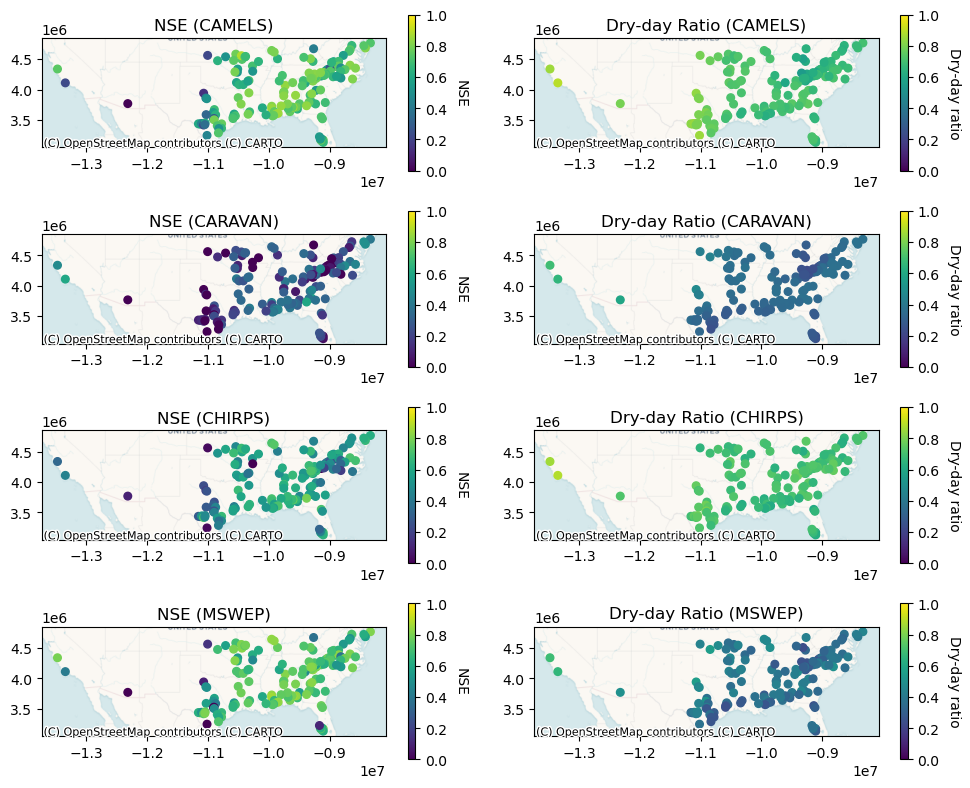

In [15]:
# --- Config ---
CONUS_BOUNDS = box(-125, 24, -66.5, 50)
conus_gdf_web = gpd.GeoDataFrame(geometry=[CONUS_BOUNDS], crs="EPSG:4326").to_crs(epsg=3857)
xmin, ymin, xmax, ymax = conus_gdf_web.total_bounds

RUN_PREFIXES = [
    "154_camels_30_epochs_seq_270_hidden_256_dropout_04_fb_05_seed111_1103_063301",
    "caravan_154_precip_seq_270_30_epochs_hidden_256_dropout_04_fb_05_seed111_0103_211409",
    "precip_chirps_precipitation_0503_093821",
    "precip_mswep_precipitation_0503_110038",
]

plot_configs = [
    ("dry_ratio_camels", "CAMELS", RUN_PREFIXES[0]),
    ("dry_ratio_caravan", "CARAVAN", RUN_PREFIXES[1]),
    ("dry_ratio_chirps",  "CHIRPS",  RUN_PREFIXES[2]),
    ("dry_ratio_mswep",   "MSWEP",   RUN_PREFIXES[3]),
]

# --- Load NSE data helper ---
def load_nse_gdf(run_prefix):
    file_path = f"../extending_caravan/runs/{run_prefix}/validation/model_epoch030/validation_results.p"
    with open(file_path, "rb") as f:
        data = pickle.load(f)

    # nse_map = {catchment: data[catchment]["1D"]["NSE"] for catchment in data}

    # attributes = pd.read_csv(location_file)

    is_camels = "camels" in run_prefix
    nse_map = {
        (f"camels_{c}" if is_camels else c): data[c]["1D"]["NSE"]
        for c in data
    }

    # print(nse_map)

    attributes = pd.read_csv(location_file)

    gdf = gpd.GeoDataFrame(
        attributes,
        geometry=gpd.points_from_xy(attributes["gauge_lon"], attributes["gauge_lat"]),
        crs="EPSG:4326"
    )

    gdf["NSE"] = gdf["gauge_id"].map(nse_map)
    gdf = gdf.dropna(subset=["NSE"])
    return gdf.to_crs(epsg=3857)

# --- Plot ---
fig, ax = plt.subplots(4, 2, figsize=(10, 8))

for row, (dry_col, label, run_prefix) in enumerate(plot_configs):

    # --- Left: NSE map ---
    nse_gdf = load_nse_gdf(run_prefix)
    nse_gdf.plot(
        column="NSE",
        cmap="viridis",
        legend=True,
        markersize=30,
        ax=ax[row, 0],
        vmin=0,
        vmax=1,
    )
    fig.axes[-1].set_ylabel(f"NSE", rotation=270, labelpad=15)
    # ax[row, 0].set_xlim(xmin, xmax)
    # ax[row, 0].set_ylim(ymin, ymax)
    cx.add_basemap(ax[row, 0], source=cx.providers.CartoDB.Voyager)
    ax[row, 0].set_title(f"NSE ({label})")

    # --- Right: Dry-day ratio map ---
    gdf_web.plot(
        column=dry_col,
        cmap="viridis",
        legend=True,
        markersize=30,
        ax=ax[row, 1],
        vmin=0,
        vmax=1,
    )
    fig.axes[-1].set_ylabel(f"Dry-day ratio", rotation=270, labelpad=15)
    # ax[row, 1].set_xlim(xmin, xmax)
    # ax[row, 1].set_ylim(ymin, ymax)
    cx.add_basemap(ax[row, 1], source=cx.providers.CartoDB.Voyager)
    ax[row, 1].set_title(f"Dry-day Ratio ({label})")

plt.tight_layout()
plt.show()

# Figure 1b

In [16]:
with open(Path("./531_caravan_vs_camels/531_basin.txt"), "r") as f:
    basins_531 = f.read().splitlines()

In [17]:
location_531 = pd.read_csv(attributes_caravan)
location_531 = location_531[location_531["gauge_id"].isin(basins_531)]
location_531.head()

,gauge_id,gauge_name,country,gauge_lat,gauge_lon,area
1,camels_01022500,"Narraguagus River at Cherryfield, Maine",United States of America,44.60797,-67.93524,619.102595
3,camels_01031500,"Piscataquis River near Dover-Foxcroft, Maine",United States of America,45.17501,-69.31470,764.824149
4,camels_01047000,"Carrabassett River near North Anson, Maine",United States of America,44.86920,-69.95510,902.895076
5,camels_01052500,"Diamond River near Wentworth Location, NH",United States of America,44.87739,-71.05749,395.444910
6,camels_01054200,"Wild River at Gilead, Maine",United States of America,44.39044,-70.97964,180.835783


In [18]:
# camels_531_dir = Path("./531_caravan_vs_camels/camelsus_30_epochs_seq_270_hidden_256_dropout_04_fb_05_seed111_0612_104002/validation/model_epoch030/validation_results.p")
# caravan_531_dir = Path("./531_caravan_vs_camels/caravan_camels_30_epochs_seq_270_hidden_256_dropout_04_fb_05_seed111_0712_110319/validation/model_epoch030/validation_results.p")

In [19]:
# camels_nse_531 = {}
# with open(camels_531_dir, "rb") as f:
#         data = pickle.load(f)
# camels_nse_531 = {catchment: data[catchment]["1D"]["NSE"] for catchment in data}
# # camels_nse_531

In [20]:
# caravan_nse_531 = {}
# with open(caravan_531_dir, "rb") as f:
#         data = pickle.load(f)
# caravan_nse_531 = {catchment: data[catchment]["1D"]["NSE"] for catchment in data}
# # caravan_nse_531

In [21]:
camels_metrics_dir = Path("./531_caravan_vs_camels/camelsus_ensemble_metrics.csv")
caravan_metrics_dir = Path("./531_caravan_vs_camels/caravan_ensemble_metrics.csv")

In [22]:
camels_metrics = pd.read_csv(camels_metrics_dir)
caravan_metrics = pd.read_csv(caravan_metrics_dir)

In [23]:
camels_metrics.head()

,basin_id,ensemble_nse,ensemble_mse,ensemble_rmse,ensemble_beta_kg,num_models
0,1022500,0.898102,0.501695,0.708304,1.040837,8
1,1031500,0.885162,1.078785,1.038646,1.084797,8
2,1047000,0.871365,1.372819,1.171674,0.964696,8
3,1052500,0.838731,2.112022,1.453280,1.041282,8
4,1054200,0.695193,8.983404,2.997233,1.044454,8


In [24]:
caravan_metrics.head()

,basin_id,ensemble_nse,ensemble_mse,ensemble_rmse,ensemble_beta_kg,num_models
0,camels_01022500,0.827383,0.849887,0.921893,0.968890,8
1,camels_01031500,0.809886,1.785963,1.336399,1.091444,8
2,camels_01047000,0.758542,2.576956,1.605290,0.965077,8
3,camels_01052500,0.782261,2.851699,1.688697,1.049747,8
4,camels_01054200,0.622852,11.115249,3.333954,1.025016,8


In [25]:
# Normalize only camels (missing prefix and leading zero)
camels_metrics['gauge_id'] = 'camels_' + camels_metrics['basin_id'].astype(str).str.zfill(8)

# caravan basin_id is already in the right format, just rename
caravan_metrics['gauge_id'] = caravan_metrics['basin_id']

# Merge only ensemble_nse columns
location_531 = location_531.merge(
    camels_metrics[['gauge_id', 'ensemble_nse']].rename(columns={'ensemble_nse': 'camels_nse'}),
    on='gauge_id', how='left'
).merge(
    caravan_metrics[['gauge_id', 'ensemble_nse']].rename(columns={'ensemble_nse': 'caravan_nse'}),
    on='gauge_id', how='left'
)

In [26]:
# Map both NSE values to the dataframe
location_531['nse_dif'] = location_531['caravan_nse'] - location_531['camels_nse']
location_531.head()

,gauge_id,gauge_name,country,gauge_lat,gauge_lon,area,camels_nse,caravan_nse,nse_dif
0,camels_01022500,"Narraguagus River at Cherryfield, Maine",United States of America,44.60797,-67.93524,619.102595,0.898102,0.827383,-0.070718
1,camels_01031500,"Piscataquis River near Dover-Foxcroft, Maine",United States of America,45.17501,-69.31470,764.824149,0.885162,0.809886,-0.075277
2,camels_01047000,"Carrabassett River near North Anson, Maine",United States of America,44.86920,-69.95510,902.895076,0.871365,0.758542,-0.112823
3,camels_01052500,"Diamond River near Wentworth Location, NH",United States of America,44.87739,-71.05749,395.444910,0.838731,0.782261,-0.056470
4,camels_01054200,"Wild River at Gilead, Maine",United States of America,44.39044,-70.97964,180.835783,0.695193,0.622852,-0.072341


In [27]:
gdf_531 = gpd.GeoDataFrame(
    location_531,
    geometry=gpd.points_from_xy(location_531['gauge_lon'], location_531['gauge_lat']),
    crs='EPSG:4326'
)
gdf_531.head()

,gauge_id,gauge_name,country,gauge_lat,gauge_lon,area,camels_nse,caravan_nse,nse_dif,geometry
0,camels_01022500,"Narraguagus River at Cherryfield, Maine",United States of America,44.60797,-67.93524,619.102595,0.898102,0.827383,-0.070718,POINT (-67.93524 44.60797)
1,camels_01031500,"Piscataquis River near Dover-Foxcroft, Maine",United States of America,45.17501,-69.31470,764.824149,0.885162,0.809886,-0.075277,POINT (-69.3147 45.17501)
2,camels_01047000,"Carrabassett River near North Anson, Maine",United States of America,44.86920,-69.95510,902.895076,0.871365,0.758542,-0.112823,POINT (-69.9551 44.8692)
3,camels_01052500,"Diamond River near Wentworth Location, NH",United States of America,44.87739,-71.05749,395.444910,0.838731,0.782261,-0.056470,POINT (-71.05749 44.87739)
4,camels_01054200,"Wild River at Gilead, Maine",United States of America,44.39044,-70.97964,180.835783,0.695193,0.622852,-0.072341,POINT (-70.97964 44.39044)


In [28]:
attributes_df = pd.read_csv(ATTRIBUTES_FILE)
# attributes_df.head()

In [29]:
gdf_531["frac_snow"]=gdf_531['gauge_id'].map(attributes_df.set_index('gauge_id')['frac_snow'])
# gdf_531.head()

154


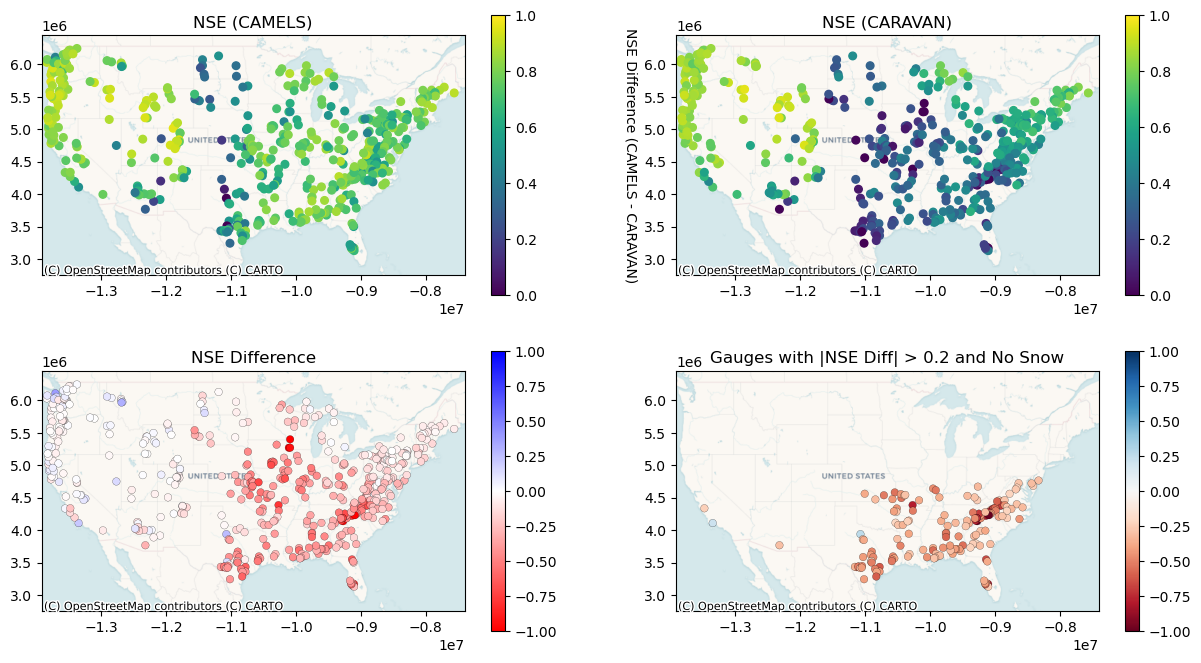

In [30]:
fig, ax = plt.subplots(2, 2, figsize=(15, 8))

gdf_531_webmercator = gdf_531.to_crs(epsg=3857)

# ---------------- Plot 1: CAMELS NSE ----------------
gdf_531_webmercator.plot(
    column='camels_nse',
    cmap='viridis',
    legend=True,
    markersize=30,
    ax=ax[0, 0],
    vmin=0,
    vmax=1
)
cbar = ax[0, 0].get_figure().get_axes()[1]
cbar.set_ylabel("NSE (CAMELS)", rotation=270, labelpad=15)
ax[0, 0].set_title("NSE (CAMELS)")
ax[0, 0].set_xlim(xmin, xmax)
ax[0, 0].set_ylim(ymin, ymax)
cx.add_basemap(ax[0, 0], source=cx.providers.CartoDB.Voyager)

# ---------------- Plot 2: CARAVAN NSE ----------------
gdf_531_webmercator.plot(
    column='caravan_nse',
    cmap='viridis',
    legend=True,
    markersize=30,
    ax=ax[0, 1],
    vmin=0,
    vmax=1
)
cbar = ax[0, 1].get_figure().get_axes()[1]
cbar.set_ylabel("NSE (CARAVAN)", rotation=270, labelpad=15)
ax[0, 1].set_title("NSE (CARAVAN)")
ax[0, 1].set_xlim(xmin, xmax)
ax[0, 1].set_ylim(ymin, ymax)
cx.add_basemap(ax[0, 1], source=cx.providers.CartoDB.Voyager)

# ---------------- Plot 3: NSE Difference ----------------
gdf_531_webmercator.plot(
    column='nse_dif',
    cmap='bwr_r',
    legend=True,
    markersize=30,
    ax=ax[1, 0],
    vmin=-1,
    vmax=1,
    edgecolor='black',
    linewidth=0.15
)

cbar = ax[1, 0].get_figure().get_axes()[1]
cbar.set_ylabel("NSE Difference (CAMELS - CARAVAN)", rotation=270, labelpad=15)
ax[1, 0].set_title("NSE Difference")
ax[1, 0].set_xlim(xmin, xmax)
ax[1, 0].set_ylim(ymin, ymax)
cx.add_basemap(ax[1, 0], source=cx.providers.CartoDB.Voyager)

# ---------------- Plot 4: NSE Difference > 0.2 (absolute filter, original values) ----------------
gdf_large_diff = gdf_531_webmercator[
    (gdf_531_webmercator['nse_dif'].abs() > 0.2) &
    (gdf_531_webmercator['frac_snow'] == 0)
]
print(gdf_large_diff.shape[0])

gdf_large_diff.plot(
    column='nse_dif',
    cmap='RdBu',
    legend=True,
    markersize=30,
    ax=ax[1, 1],
    vmin=-1,
    vmax=1,
    edgecolor='black',
    linewidth=0.15
)

cbar = ax[1, 1].get_figure().get_axes()[1]
cbar.set_ylabel("NSE Difference (CAMELS - CARAVAN)", rotation=270, labelpad=15)
ax[1, 1].set_title("Gauges with |NSE Diff| > 0.2 and No Snow")
ax[1, 1].set_xlim(xmin, xmax)
ax[1, 1].set_ylim(ymin, ymax)
cx.add_basemap(ax[1, 1], source=cx.providers.CartoDB.Voyager)

Runs that I want to include:

- Whole CAMELS and dry ratio 

# Figure 2: Precip comparison

In [31]:
idx = gdf_531['nse_dif'].idxmin()
print(gdf_531.loc[idx, 'gauge_id'], gdf_531.loc[idx, 'nse_dif'])

camels_05408000 -3.750492526262035


In [32]:
basin = gdf_531.loc[idx, 'gauge_id']
basin

'camels_05408000'

In [33]:
# basin = 'camels_01440400'
number = basin.split("_")[1]

In [34]:
extended_dataset_dir=Path(f"../extending_caravan/data/time_series")

In [35]:
camels = xr.open_dataset(extended_dataset_dir / f"{basin}.nc")
camels

<xarray.Dataset> Size: 321kB
Dimensions:                           (date: 7305)
Coordinates:
    basin                             <U15 60B ...
  * date                              (date) datetime64[ns] 58kB 1989-01-01 ....
Data variables:
    chirps_precipitation              (date) float32 29kB ...
    era5land_total_precipitation      (date) float32 29kB ...
    total_precipitation_sum           (date) float32 29kB ...
    temperature_2m_max                (date) float32 29kB ...
    temperature_2m_min                (date) float32 29kB ...
    surface_net_solar_radiation_mean  (date) float32 29kB ...
    streamflow                        (date) float32 29kB ...
    mswep_precipitation               (date) float64 58kB ...
Attributes:
    Citation:  Funk, Chris, Pete Peterson, Martin Landsfeld, Diego Pedreros, ...
    License:   To the extent possible under the law, Pete Peterson has waived...
    Product:   CHIRPS
    Released:  2024-11-18
    Sources:   CHIRPS: Rainfall Estimates from Rain Gauge and Satellite Obser...
    Units:     precipitation [mm]
    Version:   1.1

In [36]:
caravan = xr.open_dataset(data_caravan / f"{basin}.nc")
csv_files = list(data_camels.glob(f"**/{number}*.txt"))

csv_files = list(data_camels.glob(f"**/{number}*.txt"))
# if not csv_files:
#     print(f"No CSV found for {basin_id}")
#     continue
csv_file = csv_files[0]

# Load CSV
df = pd.read_csv(csv_file, skiprows=3, sep=r"\s+")
df["date"] = pd.to_datetime(
    df[["Year", "Mnth", "Day"]].rename(columns={
        "Year": "year",
        "Mnth": "month",
        "Day": "day"
    })
)
df = df.set_index("date")

In [37]:
precip_caravan = camels['total_precipitation_sum']
precip_chirps = camels['chirps_precipitation']
precip_mswep = camels['mswep_precipitation']

# # Align by date first (so we sum over the same days)
# precip_caravan = caravan['total_precipitation_sum']
precip_camels = xr.DataArray(
    df['prcp(mm/day)'],
    coords={'date': df.index},
    dims='date',
    name='prcp'
)

precip_caravan_aligned, precip_camels_aligned, precip_chirps_aligned, precip_mswep_aligned = xr.align(
    precip_caravan,
    precip_camels,
    precip_chirps,
    precip_mswep,
    join='inner'
)

In [38]:
start_date = pd.Timestamp("1989-10-01")
end_date   = pd.Timestamp("2008-09-30")

In [39]:
precip_caravan_sel = precip_caravan_aligned.sel(date=slice(start_date, end_date))
precip_camels_sel   = precip_camels_aligned.sel(date=slice(start_date, end_date))
precip_chirps_sel   = precip_chirps_aligned.sel(date=slice(start_date, end_date))
precip_mswep_sel    = precip_mswep_aligned.sel(date=slice(start_date, end_date))

In [40]:
# Compute cumulative precipitation for both series
cum_caravan = precip_caravan_sel.cumsum(dim='date').values.flatten()
cum_camels = precip_camels_sel.cumsum(dim='date').values.flatten()
cum_chirps = precip_chirps_sel.cumsum(dim='date').values.flatten()
cum_mswep = precip_mswep_sel.cumsum(dim='date').values.flatten()

In [41]:
# --- Flatten & remove NaNs ---
pr_caravan = precip_caravan_sel[~np.isnan(precip_caravan_sel)]
pr_camels = precip_camels_sel[~np.isnan(precip_caravan_sel)]
pr_chirps = precip_chirps_sel[~np.isnan(precip_caravan_sel)]
pr_mswep = precip_mswep_sel[~np.isnan(precip_caravan_sel)]

# --- Sort descending ---
pr_caravan_sorted = np.sort(pr_caravan)[::-1]
pr_camels_sorted = np.sort(pr_camels)[::-1]
pr_chirps_sorted = np.sort(pr_chirps)[::-1]
pr_mswep_sorted = np.sort(pr_mswep)[::-1]

# --- Exceedance probabilities ---
n_caravan = len(pr_caravan_sorted)
n_camels = len(pr_camels_sorted)
n_chirps = len(pr_chirps_sorted)
n_mswep = len(pr_mswep_sorted)

ep_caravan = np.arange(1, n_caravan + 1) / (n_caravan + 1) * 100
ep_camels = np.arange(1, n_camels + 1) / (n_camels + 1) * 100
ep_chirps = np.arange(1, n_chirps + 1) / (n_chirps + 1) * 100
ep_mswep = np.arange(1, n_mswep + 1) / (n_mswep + 1) * 100

# --- Plot ---
pr_caravan_plot = np.where(pr_caravan_sorted==0, 1e-5, pr_caravan_sorted)
pr_camels_plot   = np.where(pr_camels_sorted==0, 1e-5, pr_camels_sorted)
pr_chirps_plot   = np.where(pr_chirps_sorted==0, 1e-5, pr_chirps_sorted)
pr_mswep_plot    = np.where(pr_mswep_sorted==0, 1e-5, pr_mswep_sorted)

In [42]:
caravan_zero_count = np.sum(pr_caravan == 0.0).values
camels_zero_count = np.sum(pr_camels == 0.0).values
chirps_zero_count = np.sum(pr_chirps == 0.0).values
mswep_zero_count = np.sum(pr_mswep == 0.0).values


# --- Step 1: Define function to get consecutive zeros ---
def get_consecutive_lengths(bool_array):
    diff = np.diff(bool_array.astype(int))
    starts = np.where(diff == 1)[0] + 1
    ends = np.where(diff == -1)[0] + 1
    if bool_array[0]:
        starts = np.r_[0, starts]
    if bool_array[-1]:
        ends = np.r_[ends, len(bool_array)]
    lengths = ends - starts
    return lengths

# --- Step 2: Convert to boolean arrays for both datasets ---
dry_caravan = (pr_caravan == 0)
dry_camels   = (pr_camels   == 0)
dry_chirps   = (pr_chirps   == 0)
dry_mswep    = (pr_mswep    == 0)

# --- Step 3: Get consecutive zero lengths ---
dry_lengths_caravan = get_consecutive_lengths(dry_caravan)
dry_lengths_camels   = get_consecutive_lengths(dry_camels)
dry_lengths_chirps   = get_consecutive_lengths(dry_chirps)
dry_lengths_mswep    = get_consecutive_lengths(dry_mswep)

# --- Step 4: Plot histograms together ---
# plt.figure(figsize=(8,5))

max_len = max(
    dry_lengths_caravan.max(),
    dry_lengths_camels.max(),
    dry_lengths_chirps.max(),
    dry_lengths_mswep.max()
)

bins = np.arange(1, max_len + 2) - 0.5

In [43]:
# Extract arrays
precip_caravan = precip_caravan_sel.values
precip_camels = precip_camels_sel.values
precip_chirps = precip_chirps_sel.values
precip_mswep = precip_mswep_sel.values
dates = pd.to_datetime(precip_caravan_sel.date.values)

# Create dataframe
df = pd.DataFrame({
    'date': dates,
    'caravan': precip_caravan,
    'camels': precip_camels,
    'chirps': precip_chirps,
    'mswep': precip_mswep
})

# Extract year and day-of-year
df['year'] = df['date'].dt.year
df['doy'] = df['date'].dt.dayofyear

# Compute median for each day-of-year (across all years)
median_caravan = df.groupby('doy')['caravan'].median().values
median_camels = df.groupby('doy')['camels'].median().values
median_chirps = df.groupby('doy')['chirps'].median().values
median_mswep = df.groupby('doy')['mswep'].median().values

# Handle leap years
if len(median_caravan) == 366:
    median_caravan = median_caravan[:365]
if len(median_camels) == 366:
    median_camels = median_camels[:365]
if len(median_chirps) == 366:
    median_chirps = median_chirps[:365]
if len(median_mswep) == 366:
    median_mswep = median_mswep[:365]

# Stack into 2D array
all_precip = np.array([median_caravan, median_camels, median_chirps, median_mswep])

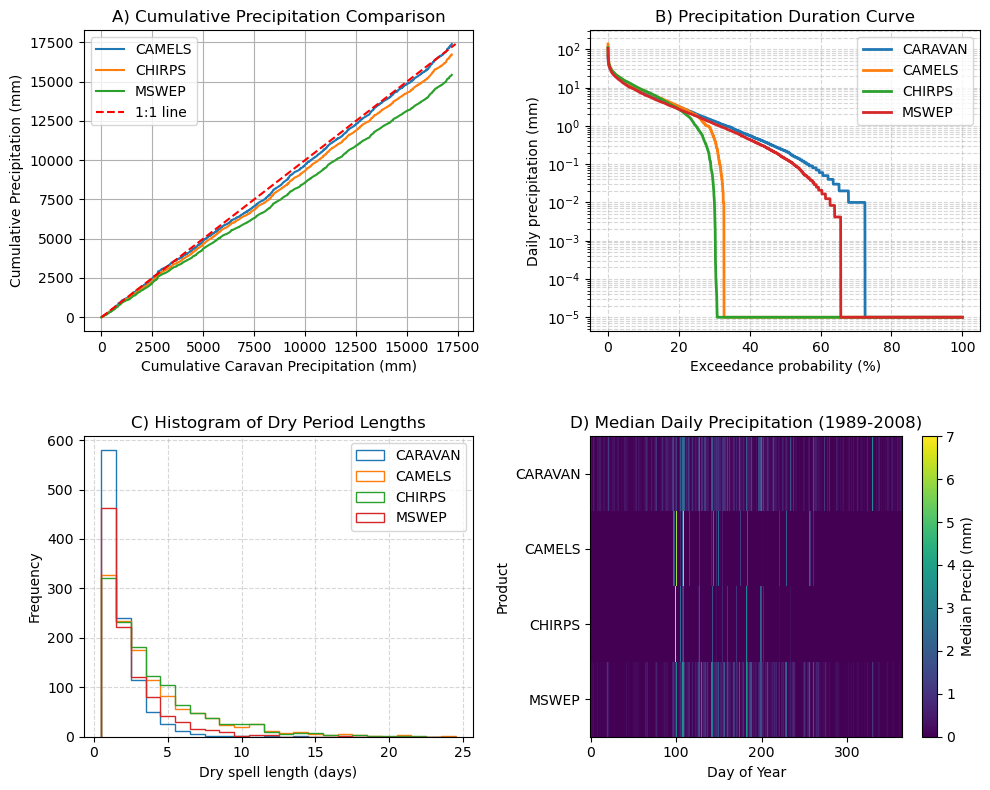

In [44]:
fix, ax = plt.subplots(2, 2, figsize=(10,8))

# ------------- Plot 1: Cumulative Precipitation Comparison -------------

# Scatter plot: x = Caravan, y = UY gauge
ax[0,0].plot(cum_caravan, cum_camels, label='CAMELS')
ax[0,0].plot(cum_caravan, cum_chirps, label='CHIRPS')
ax[0,0].plot(cum_caravan, cum_mswep, label='MSWEP')
ax[0,0].set_xlabel('Cumulative Caravan Precipitation (mm)')
ax[0,0].set_ylabel('Cumulative Precipitation (mm)')
ax[0,0].set_title('A) Cumulative Precipitation Comparison')
ax[0,0].grid(True)

# Optional: 1:1 line to see perfect agreement
max_val = max(cum_caravan.max(), cum_camels.max(), cum_chirps.max(), cum_mswep.max())
ax[0,0].plot([0, max_val], [0, max_val], 'r--', label='1:1 line')
ax[0,0].legend()

# ------------- Plot 2: Precipitation Duration Curve -------------

ax[0,1].plot(ep_caravan, pr_caravan_plot, label="CARAVAN", lw=2)
ax[0,1].plot(ep_camels, pr_camels_plot, label="CAMELS", lw=2)
ax[0,1].plot(ep_chirps, pr_chirps_plot, label="CHIRPS", lw=2)
ax[0,1].plot(ep_mswep, pr_mswep_plot, label="MSWEP", lw=2)

ax[0,1].set_xlabel("Exceedance probability (%)")
ax[0,1].set_ylabel("Daily precipitation (mm)")
ax[0,1].set_yscale("log")
ax[0,1].grid(True, which="both", ls="--", alpha=0.5)
ax[0,1].legend()
ax[0,1].set_title("B) Precipitation Duration Curve")

# ------------- Plot 3: Histogram of Dry Period Lengths -------------

ax[1,0].hist(dry_lengths_caravan, bins=bins, histtype="step", lw=2, label="CARAVAN")
ax[1,0].hist(dry_lengths_camels,   bins=bins, histtype="step", lw=2, label="CAMELS")
ax[1,0].hist(dry_lengths_chirps,   bins=bins, histtype="step", lw=2, label="CHIRPS")
ax[1,0].hist(dry_lengths_mswep,    bins=bins, histtype="step", lw=2, label="MSWEP")

ax[1,0].set_xlabel("Dry spell length (days)")
ax[1,0].set_ylabel("Frequency")
ax[1,0].set_title("C) Histogram of Dry Period Lengths")
ax[1,0].legend()
ax[1,0].grid(True, ls='--', alpha=0.5)


# ------------- Plot 4: Median Seasonal Cycle -------------

# CREATE HEATMAP
im = ax[1,1].imshow(all_precip, aspect='auto', cmap='viridis',vmin=0,vmax=7, interpolation='nearest')

ax[1,1].set_yticks([0, 1, 2, 3])
ax[1,1].set_yticklabels(['CARAVAN', 'CAMELS','CHIRPS','MSWEP'])
ax[1,1].set_xlabel('Day of Year')
ax[1,1].set_ylabel('Product')
ax[1,1].set_title('D) Median Daily Precipitation (1989-2008)')

cbar = plt.colorbar(im, ax=ax[1,1])
cbar.set_label('Median Precip (mm)')

plt.tight_layout()
plt.subplots_adjust(hspace=0.35, wspace=0.3)
plt.show()

In [45]:
def plot_precipitation_comparison(
    basin: str,
    extended_dataset_dir: Path,
    data_caravan: Path,
    data_camels: Path,
    start_date: str = "1989-10-01",
    end_date: str = "2008-09-30",
    vmax_heatmap: float = 7.0,
    save_path: Path = None,
):
    """
    Plot precipitation comparison for a single basin across four products:
    CARAVAN, CAMELS (gauge), CHIRPS, and MSWEP.

    Parameters
    ----------
    basin : str
        Basin ID, e.g. "camels_us_01013500"
    extended_dataset_dir : Path
        Directory containing extended NetCDF files (with CHIRPS/MSWEP).
    data_caravan : Path
        Directory containing original Caravan NetCDF files.
    data_camels : Path
        Directory containing CAMELS gauge txt files.
    start_date : str
        Start of analysis period (inclusive), default "1989-10-01".
    end_date : str
        End of analysis period (inclusive), default "2008-09-30".
    vmax_heatmap : float
        Max value for the seasonal heatmap colorbar, default 7.
    save_path : Path, optional
        If provided, saves the figure to this path instead of showing it.
    """
    number = basin.split("_")[-1]

    # ------------------------------------------------------------------ #
    # Load data
    # ------------------------------------------------------------------ #
    camels_nc = xr.open_dataset(extended_dataset_dir / f"{basin}.nc")
    
    csv_files = list(data_camels.glob(f"**/{number}*.txt"))
    if not csv_files:
        print(f"No gauge CSV found for {basin} — skipping.")
        return
    
    df_gauge = pd.read_csv(csv_files[0], skiprows=3, sep=r"\s+")
    df_gauge["date"] = pd.to_datetime(
        df_gauge[["Year", "Mnth", "Day"]].rename(
            columns={"Year": "year", "Mnth": "month", "Day": "day"}
        )
    )
    df_gauge = df_gauge.set_index("date")

    # ------------------------------------------------------------------ #
    # Build xarray DataArrays
    # ------------------------------------------------------------------ #
    precip_caravan = camels_nc["total_precipitation_sum"]
    precip_chirps  = camels_nc["chirps_precipitation"]
    precip_mswep   = camels_nc["mswep_precipitation"]
    precip_camels  = xr.DataArray(
        df_gauge["prcp(mm/day)"],
        coords={"date": df_gauge.index},
        dims="date",
        name="prcp",
    )

    # ------------------------------------------------------------------ #
    # Align and slice
    # ------------------------------------------------------------------ #
    precip_caravan, precip_camels, precip_chirps, precip_mswep = xr.align(
        precip_caravan, precip_camels, precip_chirps, precip_mswep, join="inner"
    )

    t0, t1 = pd.Timestamp(start_date), pd.Timestamp(end_date)
    sl = slice(t0, t1)

    caravan = precip_caravan.sel(date=sl)
    camels  = precip_camels.sel(date=sl)
    chirps  = precip_chirps.sel(date=sl)
    mswep   = precip_mswep.sel(date=sl)

    # ------------------------------------------------------------------ #
    # Cumulative sums
    # ------------------------------------------------------------------ #
    cum_caravan = caravan.cumsum(dim="date").values.flatten()
    cum_camels  = camels.cumsum(dim="date").values.flatten()
    cum_chirps  = chirps.cumsum(dim="date").values.flatten()
    cum_mswep   = mswep.cumsum(dim="date").values.flatten()

    # ------------------------------------------------------------------ #
    # Flow duration curve helpers
    # ------------------------------------------------------------------ #
    def _fdc(da):
        arr = da.values.flatten()
        arr = arr[~np.isnan(arr)]
        arr_sorted = np.sort(arr)[::-1]
        ep = np.arange(1, len(arr_sorted) + 1) / (len(arr_sorted) + 1) * 100
        arr_plot = np.where(arr_sorted == 0, 1e-5, arr_sorted)
        return ep, arr_plot

    ep_caravan, pr_caravan_plot = _fdc(caravan)
    ep_camels,  pr_camels_plot  = _fdc(camels)
    ep_chirps,  pr_chirps_plot  = _fdc(chirps)
    ep_mswep,   pr_mswep_plot   = _fdc(mswep)

    # ------------------------------------------------------------------ #
    # Dry spell lengths
    # ------------------------------------------------------------------ #
    def _dry_lengths(da):
        mask = (da.values.flatten() == 0)
        diff = np.diff(mask.astype(int))
        starts = np.where(diff == 1)[0] + 1
        ends   = np.where(diff == -1)[0] + 1
        if mask[0]:  starts = np.r_[0, starts]
        if mask[-1]: ends   = np.r_[ends, len(mask)]
        return ends - starts

    dry_caravan = _dry_lengths(caravan)
    dry_camels  = _dry_lengths(camels)
    dry_chirps  = _dry_lengths(chirps)
    dry_mswep   = _dry_lengths(mswep)

    bins = np.arange(1, max(dry_caravan.max(), dry_camels.max(),
                            dry_chirps.max(), dry_mswep.max()) + 2) - 0.5

    # ------------------------------------------------------------------ #
    # Seasonal cycle (median by DOY)
    # ------------------------------------------------------------------ #
    dates = pd.to_datetime(caravan.date.values)
    df_doy = pd.DataFrame({
        "doy":     dates.dayofyear,
        "caravan": caravan.values,
        "camels":  camels.values,
        "chirps":  chirps.values,
        "mswep":   mswep.values,
    })

    def _median_doy(col):
        med = df_doy.groupby("doy")[col].median().values
        return med[:365] if len(med) == 366 else med

    all_precip = np.array([
        _median_doy("caravan"),
        _median_doy("camels"),
        _median_doy("chirps"),
        _median_doy("mswep"),
    ])

    # ------------------------------------------------------------------ #
    # Plot
    # ------------------------------------------------------------------ #
    fig, ax = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(f"Basin: {basin}", fontsize=13, fontweight="bold")

    # A) Cumulative
    max_val = max(cum_caravan.max(), cum_camels.max(),
                  cum_chirps.max(), cum_mswep.max())
    ax[0, 0].plot(cum_caravan, cum_camels, label="CAMELS")
    ax[0, 0].plot(cum_caravan, cum_chirps, label="CHIRPS")
    ax[0, 0].plot(cum_caravan, cum_mswep,  label="MSWEP")
    ax[0, 0].plot([0, max_val], [0, max_val], "r--", label="1:1 line")
    ax[0, 0].set(xlabel="Cumulative CARAVAN (mm)",
                 ylabel="Cumulative Precipitation (mm)",
                 title="A) Cumulative Precipitation Comparison")
    ax[0, 0].legend()
    ax[0, 0].grid(True)

    # B) Flow duration curve
    for ep, pr, lbl in [
        (ep_caravan, pr_caravan_plot, "CARAVAN"),
        (ep_camels,  pr_camels_plot,  "CAMELS"),
        (ep_chirps,  pr_chirps_plot,  "CHIRPS"),
        (ep_mswep,   pr_mswep_plot,   "MSWEP"),
    ]:
        ax[0, 1].plot(ep, pr, lw=2, label=lbl)
    ax[0, 1].set(xlabel="Exceedance probability (%)",
                 ylabel="Daily precipitation (mm)",
                 title="B) Precipitation Duration Curve",
                 yscale="log")
    ax[0, 1].legend()
    ax[0, 1].grid(True, which="both", ls="--", alpha=0.5)

    # C) Dry spell histogram
    for lengths, lbl in [
        (dry_caravan, "CARAVAN"),
        (dry_camels,  "CAMELS"),
        (dry_chirps,  "CHIRPS"),
        (dry_mswep,   "MSWEP"),
    ]:
        ax[1, 0].hist(lengths, bins=bins, histtype="step", lw=2, label=lbl)
    ax[1, 0].set(xlabel="Dry spell length (days)",
                 ylabel="Frequency",
                 title="C) Histogram of Dry Period Lengths")
    ax[1, 0].legend()
    ax[1, 0].grid(True, ls="--", alpha=0.5)

    # D) Seasonal heatmap
    im = ax[1, 1].imshow(all_precip, aspect="auto", cmap="viridis",
                         vmin=0, vmax=vmax_heatmap, interpolation="nearest")
    ax[1, 1].set_yticks([0, 1, 2, 3])
    ax[1, 1].set_yticklabels(["CARAVAN", "CAMELS", "CHIRPS", "MSWEP"])
    ax[1, 1].set(xlabel="Day of Year", ylabel="Product",
                 title=f"D) Median Daily Precipitation ({start_date[:4]}–{end_date[:4]})")
    plt.colorbar(im, ax=ax[1, 1]).set_label("Median Precip (mm)")

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.35, wspace=0.3)

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved: {save_path}")
    else:
        plt.show()

In [46]:
basin

'camels_05408000'

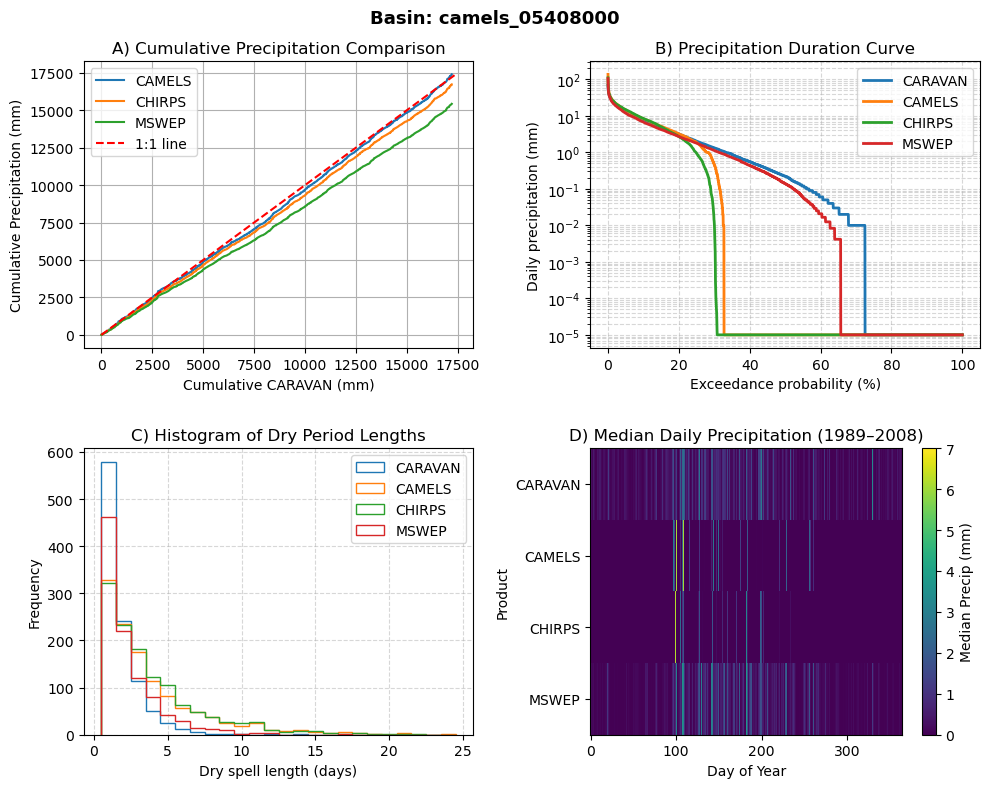

In [47]:
plot_precipitation_comparison(
        basin=basin,
        extended_dataset_dir=extended_dataset_dir,
        data_caravan=data_caravan,
        data_camels=data_camels,
        # save_path=output_dir / f"{basin}.png",  # remove to show interactively
    )

In [48]:
idx_max = gdf_531['nse_dif'].idxmax()
print(gdf_531.loc[idx_max, 'gauge_id'], gdf_531.loc[idx_max, 'nse_dif'])

camels_12048000 0.3862800338444852


In [49]:
basin_max = gdf_531.loc[idx_max, 'gauge_id']
basin_max

'camels_12048000'

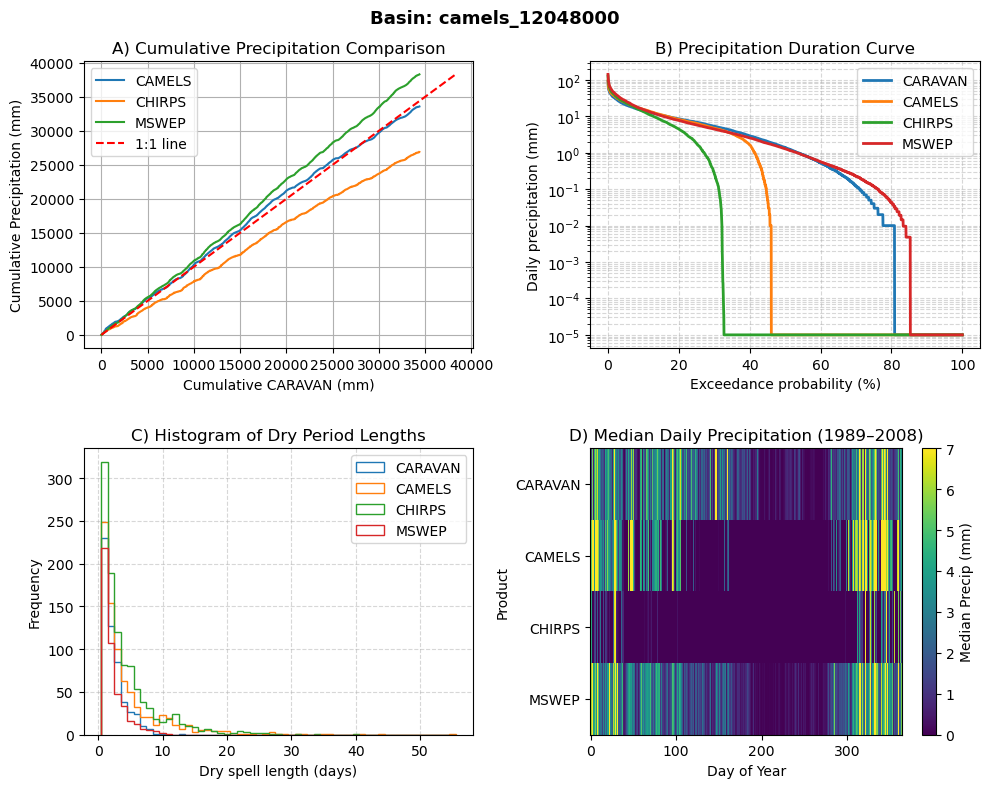

In [50]:
plot_precipitation_comparison(
        basin=basin_max,
        extended_dataset_dir=extended_dataset_dir,
        data_caravan=data_caravan,
        data_camels=data_camels,
        # save_path=output_dir / f"{basin}.png",  # remove to show interactively
    )

# Figure 3: Uruguay

In [51]:
# ---------------- US Basins data --------------------
results_df = pd.DataFrame(results)

gdf_us = gpd.GeoDataFrame(
    results_df,
    geometry=gpd.points_from_xy(results_df["gauge_lon"], results_df["gauge_lat"]),
    crs="EPSG:4326"
)

# Convert to Web Mercator
gdf_us = gdf_us.to_crs(epsg=3857)

In [52]:
# ---------------- Uruguay Basins data --------------------

attributes_caravan_csv = pd.read_csv(attributes_caravan)
attributes_uru = attributes_caravan_csv[attributes_caravan_csv["gauge_id"].str.startswith("CAMELS_UY_")]

# basins to remove
remove_ids = ["CAMELS_UY_1", "CAMELS_UY_4", "CAMELS_UY_12", "CAMELS_UY_13", "CAMELS_UY_14"]

attributes_uru = attributes_uru[~attributes_uru["gauge_id"].isin(remove_ids)]

gdf_uru = gpd.GeoDataFrame(
    attributes_uru,
    geometry=gpd.points_from_xy(attributes_uru["gauge_lon"], attributes_uru["gauge_lat"]),
    crs="EPSG:4326"
)

# Convert to Web Mercator
gdf_uru = gdf_uru.to_crs(epsg=3857)

In [63]:
# -------------------- NSE data for Uruguay basins (runs just with UY basins) -------------------

precip_products = [
    "prcp_mm_day",
    "prcp_chirps_mm_day",
    "prcp_mswep_mm_day",
    "prcp_gauge_mm_day",
]

all_combinations = [
    combo
    for r in range(1, len(precip_products) + 1)
    for combo in itertools.combinations(precip_products, r)
]

all_NSE = []
model_numbers = []
model_labels = {}
basins_order = []

for i, combo in enumerate(all_combinations, start=1):
    
    precip_name = "_".join(combo)
    # print(f"Processing: {precip_name}")

    metrics_csv = pd.read_csv(f"./ensemble_metrics/{precip_name}.csv")

    NSE = metrics_csv["NSE"].values
    
    if i == 1:
        basins_order = metrics_csv["basin"].values

    all_NSE.append(NSE)
    model_numbers.append(i)
    model_labels[i] = precip_name

# # Print mapping
# print("\nModel number mapping:")
# for num, label in model_labels.items():
#     print(f"{num}: {label}")

In [54]:
model_labels

{1: 'prcp_mm_day',
 2: 'prcp_chirps_mm_day',
 3: 'prcp_mswep_mm_day',
 4: 'prcp_gauge_mm_day',
 5: 'prcp_mm_day_prcp_chirps_mm_day',
 6: 'prcp_mm_day_prcp_mswep_mm_day',
 7: 'prcp_mm_day_prcp_gauge_mm_day',
 8: 'prcp_chirps_mm_day_prcp_mswep_mm_day',
 9: 'prcp_chirps_mm_day_prcp_gauge_mm_day',
 10: 'prcp_mswep_mm_day_prcp_gauge_mm_day',
 11: 'prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day',
 12: 'prcp_mm_day_prcp_chirps_mm_day_prcp_gauge_mm_day',
 13: 'prcp_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day',
 14: 'prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day',
 15: 'prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day'}

In [131]:
# -------------------- NSE data for Uruguay basins (runs just with UY basins) -------------------
finetune_runs_dir = Path("../extending_caravan/runs")
runs=["caravan_and_uy_chirps_and_mswep_154_precip_seq_270_30_epochs_hidden_256_dropout_04_fb_05_seed111_0203_030221",
      "finetune_UY_basins_0203_071357",
      "finetune_UY_basins_head_0203_072023",
      "finetune_UY_basins_lstm_0203_072501",
      "finetune_UY_basins_lr_0203_165949",
      "finetune_UY_basins_dropout_025_0203_180833",
      "finetune_UY_basins_seq_10_0303_190203",
      "finetune_UY_basins_seq_30_0303_185934",
      "finetune_UY_basins_seq_45_0303_185137",
      "finetune_UY_basins_seq_90_0303_185548",
      "finetune_UY_basins_seq_120_0303_190545",
      "finetune_UY_basins_seq_180_0303_193153"]

nse_per_run = {}

for run in runs:
    file_path = finetune_runs_dir / run / "validation" / "model_epoch030" / "validation_results.p"
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    nse_per_run[run] = {catchment: data[catchment]["1D"]["NSE"] for catchment in data}

nse_per_run[runs[0]] = {k: v for k, v in nse_per_run[runs[0]].items() if k.startswith("CAMELS_UY")} #he first one includes data for US basins too, i have to filter
# nse_per_run    

In [141]:
# -------------------- NSE data for US basins (runs just with US basins) -------------------
finetune_runs_dir_us = Path("../extending_caravan/runs")
runs_us=["154_camels_30_epochs_seq_270_hidden_256_dropout_04_fb_05_seed111_1103_063301",
      "caravan_154_precip_seq_270_30_epochs_hidden_256_dropout_04_fb_05_seed111_0103_211409",  # caravan
      "precip_chirps_precipitation_0503_093821",  # chirps
      "precip_mswep_precipitation_0503_110038",  # mswep
      "precip_total_precipitation_sum_chirps_precipitation_0303_072447",  # caravan + chirps
      "precip_total_precipitation_sum_mswep_precipitation_0303_084843",  # caravan + mswep
      "precip_chirps_precipitation_mswep_precipitation_0303_101255",  # chirps + mswep
      "precip_total_precipitation_sum_chirps_precipitation_mswep_precipitation_0303_113714",  # caravan + chirps + mswep
        ]

nse_per_run_us = {}

for run in runs_us:
    file_path = finetune_runs_dir_us / run / "validation" / "model_epoch030" / "validation_results.p"
    with open(file_path, "rb") as f:
        data_us = pickle.load(f)
        
    if run == runs_us[0]:
        nse_per_run_us[run] = {f"camels_{catchment}": data_us[catchment]["1D"]["NSE"] for catchment in data_us}
    else:
        nse_per_run_us[run] = {catchment: data_us[catchment]["1D"]["NSE"] for catchment in data_us}

    # nse_per_run_us[run] = {catchment: data_us[catchment]["1D"]["NSE"] for catchment in data_us}

# nse_per_run_us

In [127]:
# # ------------------------- PLOTTING -------------------------
# # fig, ax = plt.subplots(2, 2, figsize=(15, 8))
# fig, ax = plt.subplots(2, 3, figsize=(18, 8))

# # ------------------- ax[0,0]: Map of training basins with inset for Uruguay -------------------
# gdf_us.plot(
#     ax=ax[0, 0],
#     color="blue",
#     markersize=20,
#     label="US Basins"
# )

# ax[0, 0].set_title("A) Training Basins - CAMELS + URUGUAY")
# ax[0, 0].set_xlim(xmin, xmax)
# ax[0, 0].set_ylim(ymin, ymax)

# cx.add_basemap(ax[0, 0], source=cx.providers.CartoDB.Voyager)

# # Create inset axes inside ax[1,0]
# # width/height are % of parent axes, loc sets the corner position
# ax_inset = inset_axes(
#     ax[0, 0],
#     width="35%",    # inset width relative to parent
#     height="35%",   # inset height relative to parent
#     loc="upper left"  # corner: "upper right", "lower left", etc.
# )

# # Plot Uruguay inside the inset
# gdf_uru.plot(
#     ax=ax_inset,
#     color="red",
#     markersize=10,
#     label="Uruguay Basins"
# )
# cx.add_basemap(ax_inset, source=cx.providers.CartoDB.Voyager, attribution=False)
# ax_inset.text(
#     0.05, 0.95,          # x, y in axes coordinates (0-1)
#     "Uruguay",
#     transform=ax_inset.transAxes,
#     fontsize=8,
#     fontweight="bold",
#     va="top", ha="left", # anchor to top-left
#     bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=2)  # subtle background box
# )
# ax_inset.set_xticks([])
# ax_inset.set_yticks([])

# # ---------------------------- ax[0,1]: Boxplot of NSE for pretrained in UY and finetuned ----------------------------
# nse_values = [list(nse_per_run[run].values()) for run in runs]
# run_numbers = list(range(1, len(runs) + 1))

# ax[0,1].boxplot(nse_values, labels=run_numbers)
# ax[0,1].set_ylabel("NSE")
# ax[0,1].set_xlabel("Run Number")
# ax[0,1].set_title("B) NSE per fine-tuned model (pretrained on CAMELS + UY)")
# ax[0,1].set_ylim(-1, 1)

# # ---------------------------- ax[1,0]: Separate map of Uruguay basins ----------------------------
# gdf_uru.plot(
#     ax=ax[1,0],
#     color="blue",
#     markersize=20,
#     label="Uruguay Basins"
# )
# cx.add_basemap(ax[1, 0], source=cx.providers.CartoDB.Voyager)
# ax[1, 0].set_title("C) Training Basins - URUGUAY")

# # ---------------------------- ax[1,1]: Boxplot of NSE for all precipitation combinations ----------------------------
# ax[1,1].boxplot(all_NSE, labels=model_numbers)
# ax[1,1].set_ylabel("NSE")
# ax[1,1].set_xlabel("Model Number")
# ax[1,1].set_title("D) NSE per model (trained on UY)")
# ax[1,1].set_ylim(-1, 1)

# # ----------------------------- Adding table ------------------------------
# # Example summary statistics
# # table_data = pd.DataFrame({
# #     "Model": model_numbers,
# #     "Mean NSE": [np.mean(v) for v in all_NSE],
# #     "Median NSE": [np.median(v) for v in all_NSE],
# #     "Std NSE": [np.std(v) for v in all_NSE]
# # })

# table_data = pd.DataFrame({
#     "Model": list(range(1, 16)),
#     "Boxplot B": [
#         "CHIRPS + MSWEP retrained",
#         "Finetuned (head + lstm)",
#         "Finetuned (head)",
#         "Finetuned (lstm)",
#         "Finetuned (lower learning)",
#         "Finetuned (dropout)",
#         "Finetuned (seq_length = 10)",
#         "Finetuned (seq_length = 30)",
#         "Finetuned (seq_length = 45)",
#         "Finetuned (seq_length = 90)",
#         "Finetuned (seq_length = 120)",
#         "Finetuned (seq_length = 180)",
#         "-",
#         "-",
#         "-"
#     ],
#     "Boxplot D": [
#         "CARAVAN",
#         "CHIRPS",
#         "MSWEP",
#         "GAUGE",
#         "CARAVAN + CHIRPS",
#         "CARAVAN + MSWEP",
#         "CARAVAN + GAUGE",
#         "CHIRPS + MSWEP",
#         "CHIRPS + GAUGE",
#         "MSWEP + GAUGE",
#         "CARAVAN + CHIRPS + MSWEP",
#         "CARAVAN + CHIRPS + GAUGE",
#         "CARAVAN + MSWEP + GAUGE",
#         "CHIRPS + MSWEP + GAUGE",
#         "CARAVAN + CHIRPS + MSWEP + GAUGE"
#     ]
# })

# # remove the two axes in the right column
# fig.delaxes(ax[0,2])
# fig.delaxes(ax[1,2])

# # create a new axis spanning both rows
# ax_table = fig.add_subplot(1, 3, 3)
# ax_table.axis('off')

# table = ax_table.table(
#     cellText=table_data.values,
#     colLabels=table_data.columns,
#     loc="center",
#     colWidths=[0.1, 0.5, 0.65]
# )

# table.auto_set_font_size(False)
# table.set_fontsize(10)
# table.scale(1, 1.8)

# # center text in all cells
# for (row, col), cell in table.get_celld().items():
#     cell.set_text_props(ha="center", va="center")

# plt.tight_layout()
# plt.show()

/tmp/ipykernel_3088/613784983.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(nse_values_us, labels=run_numbers_us)


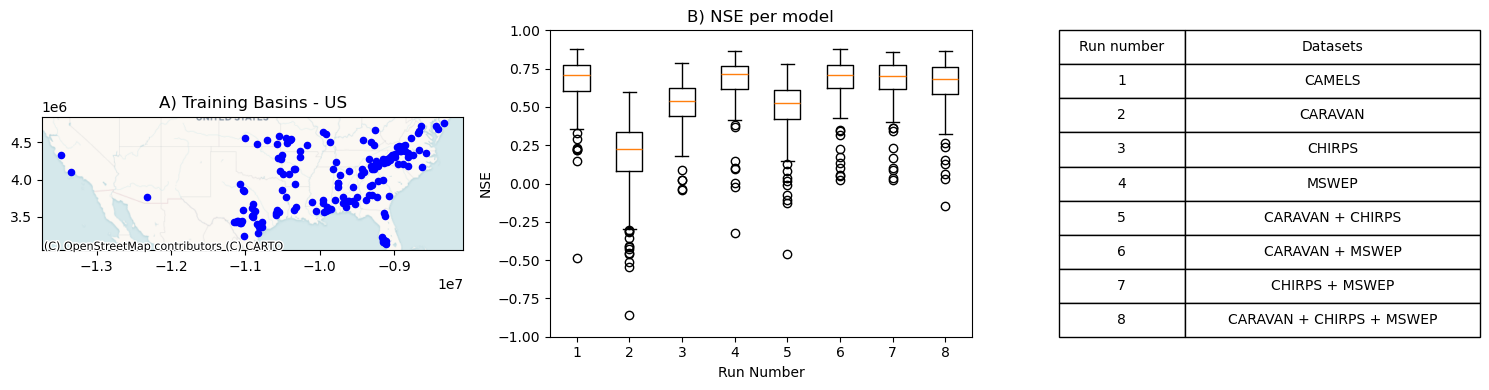

In [147]:
# ------------------------- PLOTTING -------------------------
# fig, ax = plt.subplots(2, 2, figsize=(15, 8))
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# ---------------------------- ax[1,0]: Separate map of Uruguay basins ----------------------------
gdf_us.plot(
    ax=ax[0],
    color="blue",
    markersize=20,
    label="US Basins"
)

# ax[0].set_xlim(xmin, xmax)
# ax[0].set_ylim(ymin, ymax)

cx.add_basemap(ax[0], source=cx.providers.CartoDB.Voyager)

ax[0].set_title("A) Training Basins - US")

# ---------------------------- ax[0,1]: Boxplot of NSE for US basins ----------------------------
nse_values_us = [list(nse_per_run_us[run].values()) for run in runs_us]
run_numbers_us = list(range(1, len(runs_us) + 1))

ax[1].boxplot(nse_values_us, labels=run_numbers_us)
ax[1].set_ylabel("NSE")
ax[1].set_xlabel("Run Number")
ax[1].set_title("B) NSE per model")
ax[1].set_ylim(-1, 1)
# ----------------------------- Adding table ------------------------------
# Example summary statistics
# table_data = pd.DataFrame({
#     "Model": model_numbers,
#     "Mean NSE": [np.mean(v) for v in all_NSE],
#     "Median NSE": [np.median(v) for v in all_NSE],
#     "Std NSE": [np.std(v) for v in all_NSE]
# })

table_data = pd.DataFrame({
    "Run number": list(range(1, len(runs_us) + 1)),
    "Datasets": [
        "CAMELS",
        "CARAVAN",
        "CHIRPS",
        "MSWEP",
        "CARAVAN + CHIRPS",
        "CARAVAN + MSWEP",
        "CHIRPS + MSWEP",
        "CARAVAN + CHIRPS + MSWEP",
    ]
})

ax_table = ax[2]
ax_table.axis('off')

table = ax_table.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    bbox=[0, 0, 1, 1],        # [x, y, width, height] in axes coordinates
    colWidths=[0.3, 0.7]      # proportions that sum to 1
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# center text in all cells
for (row, col), cell in table.get_celld().items():
    cell.set_text_props(ha="center", va="center")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3088/3745694957.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(all_NSE, labels=model_numbers)


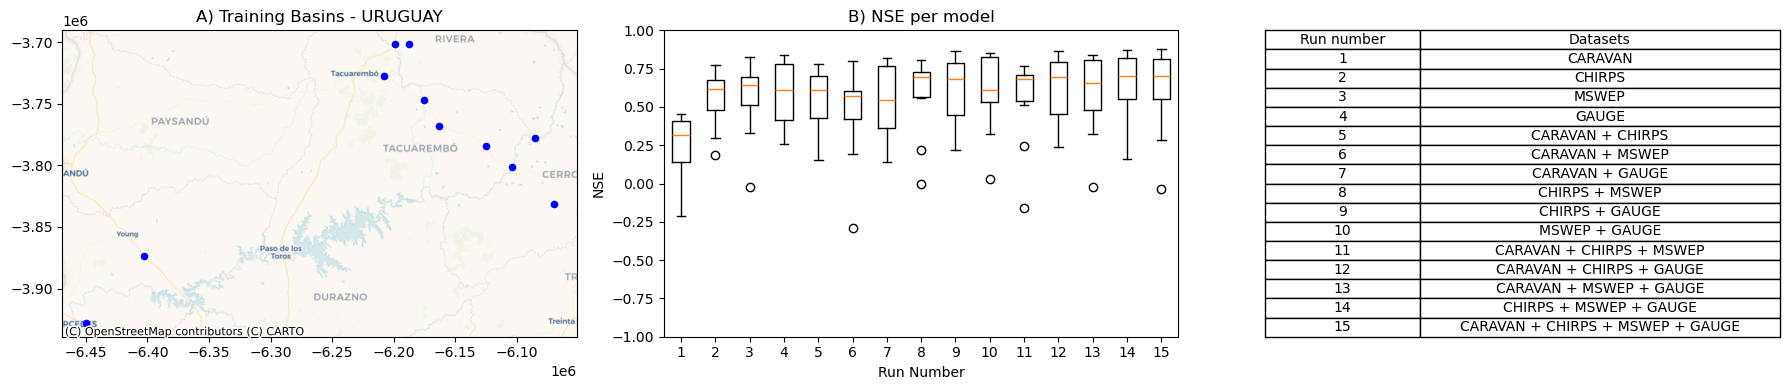

In [126]:
# ------------------------- PLOTTING -------------------------
# fig, ax = plt.subplots(2, 2, figsize=(15, 8))
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
# ---------------------------- ax[1,0]: Separate map of Uruguay basins ----------------------------
gdf_uru.plot(
    ax=ax[0],
    color="blue",
    markersize=20,
    label="Uruguay Basins"
)
cx.add_basemap(ax[0], source=cx.providers.CartoDB.Voyager)
ax[0].set_title("A) Training Basins - URUGUAY")

# ---------------------------- ax[1,1]: Boxplot of NSE for all precipitation combinations ----------------------------
ax[1].boxplot(all_NSE, labels=model_numbers)
ax[1].set_ylabel("NSE")
ax[1].set_xlabel("Run Number")
ax[1].set_title("B) NSE per model")
ax[1].set_ylim(-1, 1)

# ----------------------------- Adding table ------------------------------
# Example summary statistics
# table_data = pd.DataFrame({
#     "Model": model_numbers,
#     "Mean NSE": [np.mean(v) for v in all_NSE],
#     "Median NSE": [np.median(v) for v in all_NSE],
#     "Std NSE": [np.std(v) for v in all_NSE]
# })

table_data = pd.DataFrame({
    "Run number": list(range(1, 16)),
    "Datasets": [
        "CARAVAN",
        "CHIRPS",
        "MSWEP",
        "GAUGE",
        "CARAVAN + CHIRPS",
        "CARAVAN + MSWEP",
        "CARAVAN + GAUGE",
        "CHIRPS + MSWEP",
        "CHIRPS + GAUGE",
        "MSWEP + GAUGE",
        "CARAVAN + CHIRPS + MSWEP",
        "CARAVAN + CHIRPS + GAUGE",
        "CARAVAN + MSWEP + GAUGE",
        "CHIRPS + MSWEP + GAUGE",
        "CARAVAN + CHIRPS + MSWEP + GAUGE"
    ]
})

ax_table = ax[2]
ax_table.axis('off')

table = ax_table.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    bbox=[0, 0, 1, 1],        # [x, y, width, height] in axes coordinates
    colWidths=[0.3, 0.7]      # proportions that sum to 1
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# center text in all cells
for (row, col), cell in table.get_celld().items():
    cell.set_text_props(ha="center", va="center")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3088/1508588704.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(nse_values, labels=run_numbers)
/tmp/ipykernel_3088/1508588704.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


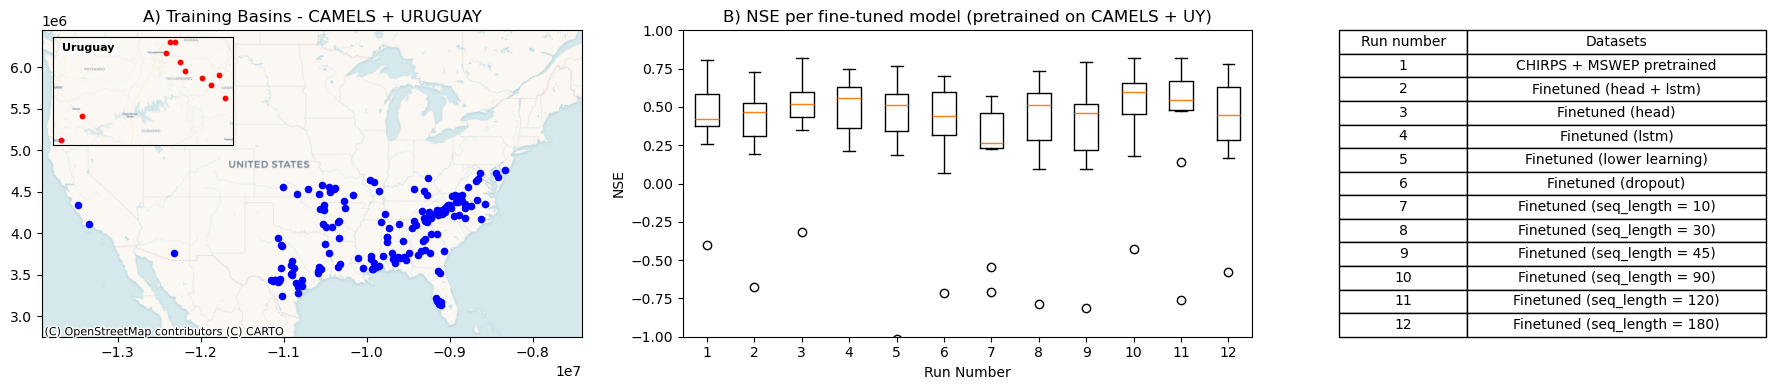

In [120]:
# ------------------------- PLOTTING -------------------------
# fig, ax = plt.subplots(2, 2, figsize=(15, 8))
fig, ax = plt.subplots(1, 3, figsize=(18, 4),
                       gridspec_kw={'width_ratios': [2, 2, 1.5]})

# ------------------- ax[0,0]: Map of training basins with inset for Uruguay -------------------
gdf_us.plot(
    ax=ax[0],
    color="blue",
    markersize=20,
    label="US Basins"
)

ax[0].set_title("A) Training Basins - CAMELS + URUGUAY")
ax[0].set_xlim(xmin, xmax)
ax[0].set_ylim(ymin, ymax)

cx.add_basemap(ax[0], source=cx.providers.CartoDB.Voyager)

# Create inset axes inside ax[1,0]
# width/height are % of parent axes, loc sets the corner position
ax_inset = inset_axes(
    ax[0],
    width="35%",    # inset width relative to parent
    height="35%",   # inset height relative to parent
    loc="upper left"  # corner: "upper right", "lower left", etc.
)

# Plot Uruguay inside the inset
gdf_uru.plot(
    ax=ax_inset,
    color="red",
    markersize=10,
    label="Uruguay Basins"
)
cx.add_basemap(ax_inset, source=cx.providers.CartoDB.Voyager, attribution=False)
ax_inset.text(
    0.05, 0.95,          # x, y in axes coordinates (0-1)
    "Uruguay",
    transform=ax_inset.transAxes,
    fontsize=8,
    fontweight="bold",
    va="top", ha="left", # anchor to top-left
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=2)  # subtle background box
)
ax_inset.set_xticks([])
ax_inset.set_yticks([])

# ---------------------------- ax[0,1]: Boxplot of NSE for pretrained in UY and finetuned ----------------------------
nse_values = [list(nse_per_run[run].values()) for run in runs]
run_numbers = list(range(1, len(runs) + 1))

ax[1].boxplot(nse_values, labels=run_numbers)
ax[1].set_ylabel("NSE")
ax[1].set_xlabel("Run Number")
ax[1].set_title("B) NSE per fine-tuned model (pretrained on CAMELS + UY)")
ax[1].set_ylim(-1, 1)


# ----------------------------- Adding table ------------------------------

table_data = pd.DataFrame({
    "Run number": list(range(1, 13)),
    "Datasets": [
        "CHIRPS + MSWEP pretrained",
        "Finetuned (head + lstm)",
        "Finetuned (head)",
        "Finetuned (lstm)",
        "Finetuned (lower learning)",
        "Finetuned (dropout)",
        "Finetuned (seq_length = 10)",
        "Finetuned (seq_length = 30)",
        "Finetuned (seq_length = 45)",
        "Finetuned (seq_length = 90)",
        "Finetuned (seq_length = 120)",
        "Finetuned (seq_length = 180)",
    ]
})

ax_table = ax[2]

ax_table.axis('off')

# table = ax_table.table(
#     cellText=table_data.values,
#     colLabels=table_data.columns,
#     loc="center",
#     colWidths=[0.25, 0.5]
# )

table = ax_table.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    bbox=[0, 0, 1, 1],        # [x, y, width, height] in axes coordinates
    colWidths=[0.3, 0.7]      # proportions that sum to 1
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# center text in all cells
for (row, col), cell in table.get_celld().items():
    cell.set_text_props(ha="center", va="center")

plt.tight_layout()
plt.show()

# Figure 4

In [79]:
nse_columns = [np.asarray(nse).reshape(-1) for nse in all_NSE]

if len(nse_columns) == 0:
    raise ValueError("all_NSE is empty. Run the NSE-loading cell first.")

n_basins = len(nse_columns[0])
if not all(len(col) == n_basins for col in nse_columns):
    raise ValueError("All NSE arrays in all_NSE must have the same length.")

if len(basins_order) != n_basins:
    raise ValueError("Length of basins_order must match NSE array length.")

if len(model_numbers) != len(nse_columns):
    raise ValueError("Length of model_numbers must match number of NSE arrays.")

# Build matrix with shape (n_basins, n_models)
nse_matrix = np.column_stack(nse_columns)

# # Use model labels as column names while preserving model numbers
# column_names = [f"M{m:02d}_{model_labels.get(m, 'unknown')}" for m in model_numbers]

nse_df = pd.DataFrame(
    nse_matrix,
    index=pd.Index(basins_order, name="basin"),
    columns=model_numbers,
)

# Optional helper table (model number -> label)
model_info_df = pd.DataFrame({
    "model_number": model_numbers,
    "model_label": [model_labels.get(m, "unknown") for m in model_numbers],
})

nse_df.head()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
basin,,,,,,,,,,,,,,,
CAMELS_UY_10,-0.211190,0.440115,0.643053,0.256841,0.327030,0.588583,0.141405,0.575763,0.221422,0.513510,0.561135,0.236483,0.478769,0.497695,0.510874
CAMELS_UY_11,0.132890,0.187004,-0.022437,0.354016,0.154163,-0.290600,0.284612,-0.001924,0.265451,0.026448,-0.159274,0.301370,-0.019987,0.159634,-0.035412
CAMELS_UY_15,0.326983,0.623255,0.714225,0.758671,0.609710,0.685666,0.730731,0.706826,0.769712,0.819925,0.714041,0.769336,0.806632,0.809688,0.806581
CAMELS_UY_16,0.091909,0.299137,0.328718,0.385586,0.270194,0.189676,0.350920,0.220539,0.311019,0.324897,0.244785,0.318212,0.321580,0.324008,0.281048
CAMELS_UY_2,0.315196,0.687356,0.608003,0.449518,0.744572,0.477272,0.376177,0.696400,0.643434,0.554639,0.683609,0.626174,0.475649,0.661280,0.650674


Number of basins: 11
['CAMELS_UY_10', 'CAMELS_UY_11', 'CAMELS_UY_15', 'CAMELS_UY_16', 'CAMELS_UY_2', 'CAMELS_UY_3', 'CAMELS_UY_5', 'CAMELS_UY_6', 'CAMELS_UY_7', 'CAMELS_UY_8', 'CAMELS_UY_9']


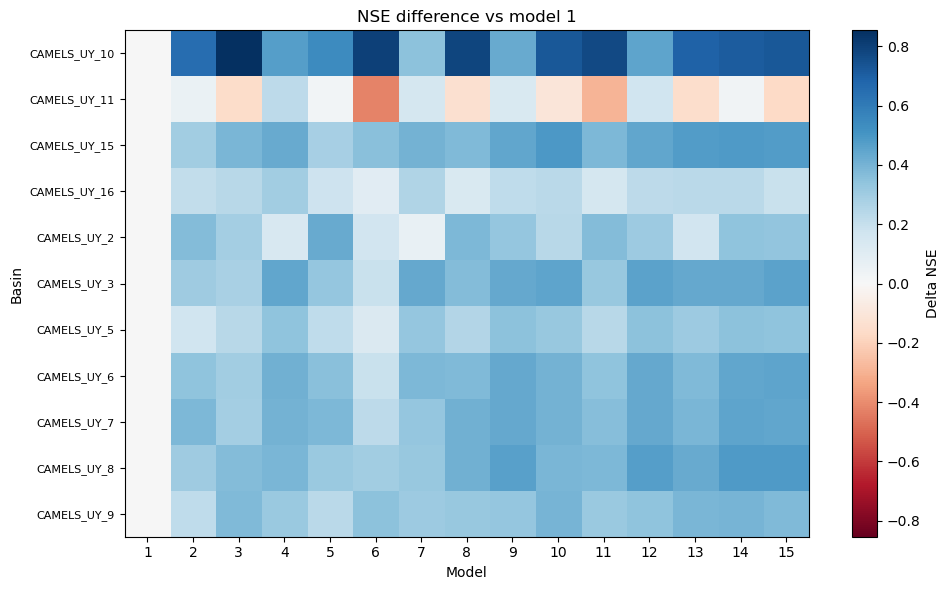

In [85]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Difference vs first model (column 1)
nse_diff_df = nse_df.subtract(nse_df.iloc[:, 0], axis=0)

# Full basin list
basin_numbers = nse_diff_df.index.tolist()
print(f"Number of basins: {len(basin_numbers)}")
print(basin_numbers)

# Easy size control: (width, height)
# Height is set to show all basin labels more clearly
figsize = (10, max(6, len(basin_numbers) * 0.35))

vals = nse_diff_df.to_numpy()
lim = max(abs(vals.min()), abs(vals.max()))
if lim == 0:
    lim = 1e-6

fig, ax = plt.subplots(figsize=figsize)
im = ax.imshow(
    vals,
    aspect="auto",
    cmap="RdBu",
    norm=TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim),
)

ax.set_xticks(range(nse_diff_df.shape[1]))
ax.set_xticklabels(nse_diff_df.columns)

# Show all basins on y-axis
ax.set_yticks(range(nse_diff_df.shape[0]))
ax.set_yticklabels(basin_numbers, fontsize=8)

ax.set_xlabel("Model")
ax.set_ylabel("Basin")
ax.set_title(f"NSE difference vs model {nse_df.columns[0]}")

fig.colorbar(im, ax=ax, label="Delta NSE")
plt.tight_layout()
plt.show()

# nse_diff_df.head()

In [99]:
def plot_precipitation_comparison_uy(
    basin: str,
    extended_dataset_dir: Path,
    start_date: str = "1989-10-01",
    end_date: str = "2008-09-30",
    vmax_heatmap: float = 7.0,
    save_path: Path = None,
):
    """
    Plot precipitation comparison for a single basin across four products:
    CARAVAN, gauge, CHIRPS, and MSWEP.

    Parameters
    ----------
    basin : str
        Basin ID, e.g. "CAMELS_UY_*"
    extended_dataset_dir : Path
        Directory containing extended NetCDF files (with CHIRPS/MSWEP).
    start_date : str
        Start of analysis period (inclusive), default "1989-10-01".
    end_date : str
        End of analysis period (inclusive), default "2008-09-30".
    vmax_heatmap : float
        Max value for the seasonal heatmap colorbar, default 7.
    save_path : Path, optional
        If provided, saves the figure to this path instead of showing it.
    """

    # ------------------------------------------------------------------ #
    # Load data
    # ------------------------------------------------------------------ #
    data_nc = xr.open_dataset(extended_dataset_dir / f"{basin}.nc")

    # ------------------------------------------------------------------ #
    # Build xarray DataArrays
    # ------------------------------------------------------------------ #
    precip_caravan = data_nc["prcp_mm_day"]
    precip_chirps  = data_nc["prcp_chirps_mm_day"]
    precip_mswep   = data_nc["prcp_mswep_mm_day"]
    precip_gauge = data_nc["prcp_gauge_mm_day"]

    # ------------------------------------------------------------------ #
    # Align and slice
    # ------------------------------------------------------------------ #
    precip_caravan, precip_gauge, precip_chirps, precip_mswep = xr.align(
        precip_caravan, precip_gauge, precip_chirps, precip_mswep, join="inner"
    )

    t0, t1 = pd.Timestamp(start_date), pd.Timestamp(end_date)
    sl = slice(t0, t1)

    caravan = precip_caravan.sel(date=sl)
    gauge  = precip_gauge.sel(date=sl)
    chirps  = precip_chirps.sel(date=sl)
    mswep   = precip_mswep.sel(date=sl)

    # ------------------------------------------------------------------ #
    # Cumulative sums
    # ------------------------------------------------------------------ #
    cum_caravan = caravan.cumsum(dim="date").values.flatten()
    cum_gauge  = gauge.cumsum(dim="date").values.flatten()
    cum_chirps  = chirps.cumsum(dim="date").values.flatten()
    cum_mswep   = mswep.cumsum(dim="date").values.flatten()

    # ------------------------------------------------------------------ #
    # Flow duration curve helpers
    # ------------------------------------------------------------------ #
    def _fdc(da):
        arr = da.values.flatten()
        arr = arr[~np.isnan(arr)]
        arr_sorted = np.sort(arr)[::-1]
        ep = np.arange(1, len(arr_sorted) + 1) / (len(arr_sorted) + 1) * 100
        arr_plot = np.where(arr_sorted == 0, 1e-9, arr_sorted)
        return ep, arr_plot

    ep_caravan, pr_caravan_plot = _fdc(caravan)
    ep_gauge,  pr_gauge_plot  = _fdc(gauge)
    ep_chirps,  pr_chirps_plot  = _fdc(chirps)
    ep_mswep,   pr_mswep_plot   = _fdc(mswep)

    # ------------------------------------------------------------------ #
    # Dry spell lengths
    # ------------------------------------------------------------------ #
    def _dry_lengths(da):
        mask = (da.values.flatten() == 0)
        diff = np.diff(mask.astype(int))
        starts = np.where(diff == 1)[0] + 1
        ends   = np.where(diff == -1)[0] + 1
        if mask[0]:  starts = np.r_[0, starts]
        if mask[-1]: ends   = np.r_[ends, len(mask)]
        return ends - starts

    dry_caravan = _dry_lengths(caravan)
    dry_gauge  = _dry_lengths(gauge)
    dry_chirps  = _dry_lengths(chirps)
    dry_mswep   = _dry_lengths(mswep)

    bins = np.arange(1, max(dry_caravan.max(), dry_gauge.max(),
                            dry_chirps.max(), dry_mswep.max()) + 2) - 0.5

    # ------------------------------------------------------------------ #
    # Seasonal cycle (median by DOY)
    # ------------------------------------------------------------------ #
    dates = pd.to_datetime(caravan.date.values)
    df_doy = pd.DataFrame({
        "doy":     dates.dayofyear,
        "caravan": caravan.values,
        "gauge":  gauge.values,
        "chirps":  chirps.values,
        "mswep":   mswep.values,
    })

    def _median_doy(col):
        med = df_doy.groupby("doy")[col].median().values
        return med[:365] if len(med) == 366 else med

    all_precip = np.array([
        _median_doy("caravan"),
        _median_doy("gauge"),
        _median_doy("chirps"),
        _median_doy("mswep"),
    ])

    # ------------------------------------------------------------------ #
    # Plot
    # ------------------------------------------------------------------ #
    fig, ax = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(f"Basin: {basin}", fontsize=13, fontweight="bold")

    # A) Cumulative
    max_val = max(cum_caravan.max(), cum_gauge.max(),
                  cum_chirps.max(), cum_mswep.max())
    ax[0, 0].plot(cum_caravan, cum_gauge, label="GAUGE")
    ax[0, 0].plot(cum_caravan, cum_chirps, label="CHIRPS")
    ax[0, 0].plot(cum_caravan, cum_mswep,  label="MSWEP")
    ax[0, 0].plot([0, max_val], [0, max_val], "r--", label="1:1 line")
    ax[0, 0].set(xlabel="Cumulative CARAVAN (mm)",
                 ylabel="Cumulative Precipitation (mm)",
                 title="A) Cumulative Precipitation Comparison")
    ax[0, 0].legend()
    ax[0, 0].grid(True)

    # B) Flow duration curve
    for ep, pr, lbl in [
        (ep_caravan, pr_caravan_plot, "CARAVAN"),
        (ep_gauge,  pr_gauge_plot,  "GAUGE"),
        (ep_chirps,  pr_chirps_plot,  "CHIRPS"),
        (ep_mswep,   pr_mswep_plot,   "MSWEP"),
    ]:
        ax[0, 1].plot(ep, pr, lw=2, label=lbl)
    ax[0, 1].set(xlabel="Exceedance probability (%)",
                 ylabel="Daily precipitation (mm)",
                 title="B) Precipitation Duration Curve",
                 yscale="log")
    ax[0, 1].legend()
    ax[0, 1].grid(True, which="both", ls="--", alpha=0.5)

    # C) Dry spell histogram
    for lengths, lbl in [
        (dry_caravan, "CARAVAN"),
        (dry_gauge,  "GAUGE"),
        (dry_chirps,  "CHIRPS"),
        (dry_mswep,   "MSWEP"),
    ]:
        ax[1, 0].hist(lengths, bins=bins, histtype="step", lw=2, label=lbl)
    ax[1, 0].set(xlabel="Dry spell length (days)",
                 ylabel="Frequency",
                 title="C) Histogram of Dry Period Lengths")
    ax[1, 0].legend()
    ax[1, 0].grid(True, ls="--", alpha=0.5)

    # D) Seasonal heatmap
    im = ax[1, 1].imshow(all_precip, aspect="auto", cmap="viridis",
                         vmin=0, vmax=vmax_heatmap, interpolation="nearest")
    ax[1, 1].set_yticks([0, 1, 2, 3])
    ax[1, 1].set_yticklabels(["CARAVAN", "GAUGE", "CHIRPS", "MSWEP"])
    ax[1, 1].set(xlabel="Day of Year", ylabel="Product",
                 title=f"D) Median Daily Precipitation ({start_date[:4]}–{end_date[:4]})")
    plt.colorbar(im, ax=ax[1, 1]).set_label("Median Precip (mm)")

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.35, wspace=0.3)

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved: {save_path}")
    else:
        plt.show()

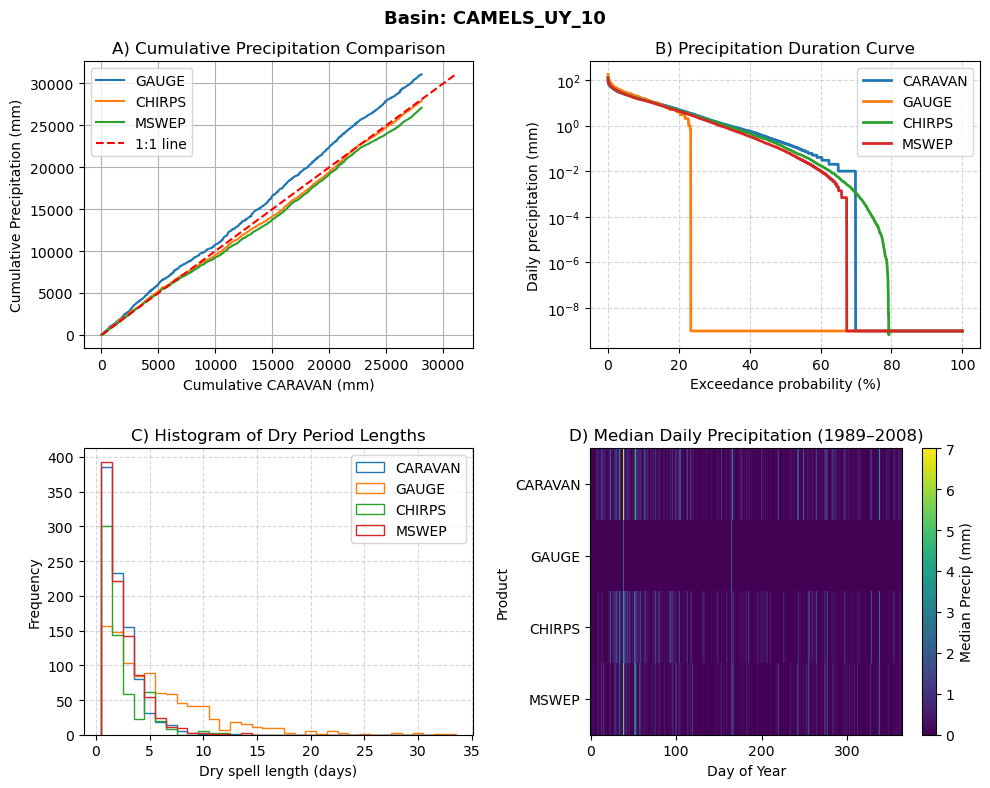

In [100]:
plot_precipitation_comparison_uy(
        basin="CAMELS_UY_10",
        extended_dataset_dir=Path("./data/time_series"),
        # data_caravan=data_caravan,
        # data_camels=data_camels,
        # save_path=output_dir / f"{basin}.png",  # remove to show interactively
    )

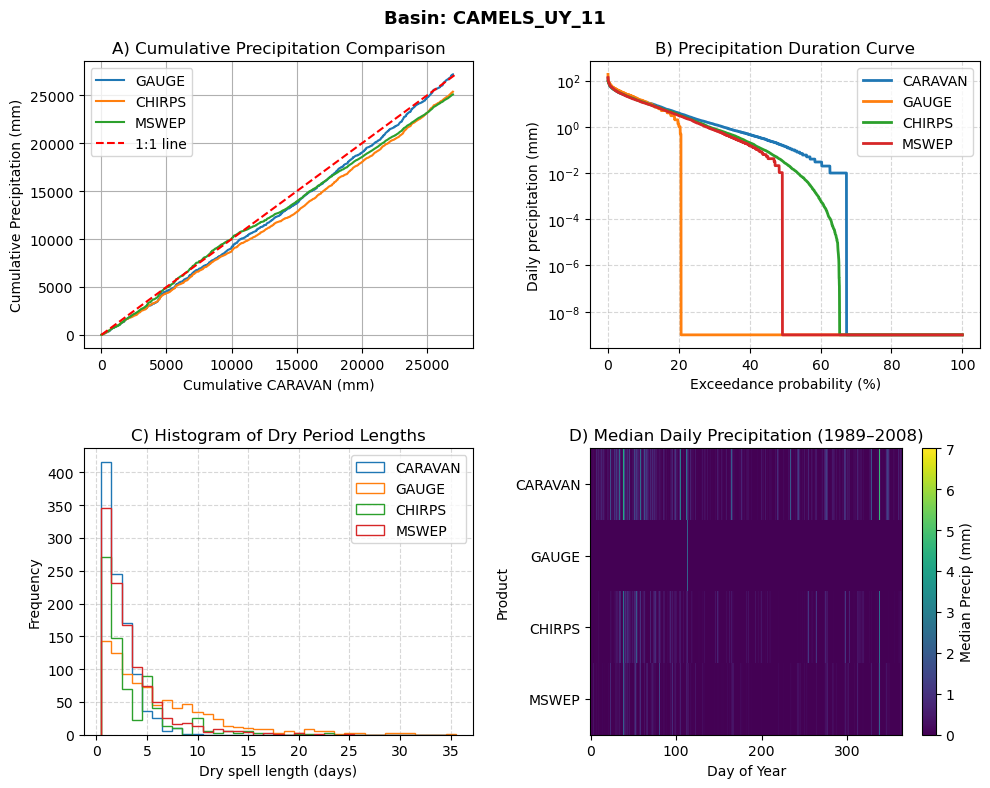

In [101]:
plot_precipitation_comparison_uy(
        basin="CAMELS_UY_11",
        extended_dataset_dir=Path("./data/time_series"),
        # data_caravan=data_caravan,
        # data_camels=data_camels,
        # save_path=output_dir / f"{basin}.png",  # remove to show interactively
    )